# Validation of parameter optimization of coarse grained nanomotif model

Bayesian optimization with BoTorch implementation

Validating optimization of CG X-motifs by selecting target angle distribution from CG simulations.

Bayesian optimization set up as 1D+(4D&1D)+1D+1D problem (split optimization) or as (5D&1D)+1D+1D problem (combined optimization)


Updated to fix error with using correlated samples in KS test


In [1]:
%load_ext autoreload
%autoreload 2

# Import

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import readdy
import math
import scipy
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
import contextlib
import io
import pickle
import torch
from botorch.models import SingleTaskGP
from botorch.models.transforms import Normalize, Standardize
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood
from gpytorch.likelihoods import FixedNoiseGaussianLikelihood
from botorch.acquisition import LogExpectedImprovement
from botorch.acquisition import ExpectedImprovement
from botorch.acquisition import UpperConfidenceBound
from botorch.optim import optimize_acqf

from scipy.stats import wasserstein_distance,kstest


import sys
import os
#sys.path.append(os.path.abspath(os.path.join('..', 'python_scripts')))

from NCG_readdy_sim_4 import Debye_length, Debye_Hueckel_pot_rep_strength ,Diff_at23C,visc_T,Diff_ES

from NCG_readdy_sim_4 import run_sim_3,tcl_file_gen_3,all_types

from NCG_Bay_opt_readdy_sim_3 import run_p,run_p_dict,gt_1_3,gt_1_1,gt_1_2,gt_1_4, cg_angle_distr_c1_4_ba_aa_oa_la,cg_angle_distr_c1_1_hp,cg_angle_distr_c1_1_bm, eval_sim_c1_1_la,eval_sim_c1_1_hp,eval_sim_c1_1_aa,eval_sim_c1_2_ba_oa,eval_sim_c1_3_aa_ba_oa, eval_sim_c1_4_ba_aa_oa_la,eval_sim_c1_1_bm,apply_gp, run_gp_11

from NCG_Bay_opt_readdy_sim_3 import gen_all_comb_from_list_of_lists_2, gt_1_1

# Units and temperature

In [3]:
#Set units used in ReaDDy and simulation temperature
custom_units = {'length_unit':'nanometer',
                'time_unit': 'nanoseconds',
                'energy_unit': 'joule'}
system_temperature=273.15 + 20  #293
kbt=system_temperature*1.380649*10**-23

# Diffusion constant

In [4]:
#Diffusion constant either based on Einstein-Smoluchowski, or on exp results for oligos at 23°C
# viscositiy: https://srd.nist.gov/jpcrdreprint/1.555581.pdf
# scaling diffusion constant with T: https://en.wikipedia.org/wiki/Einstein_relation_(kinetic_theory)
# Diffusion constant DNA oligos at 23°C: https://www.sciencedirect.com/science/article/pii/S0021925818310871


#Diffusion const for BP of ds DNA (known at 23°C)
Diff_at23C_1=Diff_at23C(8)

#Viscosity water at sim temp and 23°C
visc_T_sys=visc_T(system_temperature)
visc_T_23=visc_T(273.15+23)

#rescale diffusion const to sim temperature and viscosity (assume scaling like Einstein-Smoluchowski D= kb*T/(6*pi*r*visc) )
Diff_sys_temp=Diff_at23C_1*system_temperature/(23+273.15)  *visc_T_23/visc_T_sys

#use Einstein-Smoluchowski for sphere
Diff_sys_temp_ES=Diff_ES(T=system_temperature,r=2.72/2 *10**-9,eta=visc_T_sys)*10**9
Diff_T_23_ES=Diff_ES(T=23+273.15,r=2.72/2 *10**-9,eta=visc_T_sys)*10**9


print("D for 8bp at 23°C /",23+273.15,"K =",Diff_at23C_1,"nm^2/ns") 
print("D for sphere with r=2.72/2 nm at 23°C /",23+273.15,"K =", Diff_T_23_ES,"nm^2/ns")
print("############################################")
print("mu at",system_temperature-273.15,"°C /", system_temperature,"K =",visc_T_sys," Pa*s" )
print("mu at","23°C /", 23+273.15,"K =" ,visc_T_23," Pa*s" )
print("############################################")
print("D for 8bp at",system_temperature-273.15,"°C /",system_temperature,"K =",Diff_sys_temp,"nm^2/ns")
print("D for sphere with r=2.72/2 nm at" ,system_temperature-273.15,"°C /",system_temperature,"K =",Diff_sys_temp_ES,"nm^2/ns")


D for 8bp at 23°C / 296.15 K = 0.10964057118867664 nm^2/ns
D for sphere with r=2.72/2 nm at 23°C / 296.15 K = 0.15917954782180455 nm^2/ns
############################################
mu at 20.0 °C / 293.15 K = 0.0010019999999999999  Pa*s
mu at 23°C / 296.15 K = 0.0009322679783769826  Pa*s
############################################
D for 8bp at 20.0 °C / 293.15 K = 0.10097700765460783 nm^2/ns
D for sphere with r=2.72/2 nm at 20.0 °C / 293.15 K = 0.15756705873362153 nm^2/ns


# Fixed model parameters

In [5]:
###################
#fixed params:
###################

#bond potential
k_bond_ds=2*10**-19
k_bond_ss=1*10**-19

#bond eq. distance
eq_dist_bb=2.72 

#bond eq. distance fused sticky-ends
eq_dist_fused_bb=2/3 *2.72
eq_dist_bb_s=2/3 *2.72 # distance arm-stickyend

#bond potential surf
k_angle_ss_surf=2e-20  #2.8666666666666663e-20     #2*10**-21
k_angle_ds_surf=3.6666666666666664e-20     #2*10**-20

#angle between monomers V=k*(theta-theta_0)^2
theta_0=np.pi
theta_90=np.pi/2

theta_60=np.pi *1/3
theta_120=np.pi * 2/3
theta_270=np.pi * 3/2
theta_base_y=np.pi*2/3

#volume exclusion
#har rep
k_ex_ds_ds=2*10**-20  *5
k_ex_ss_ds=8*10**-21  *5
k_ex_ss_ss=4*10**-21  *5
dist_ex=1.5          *1 

#DH
c_NaCl = 150 # NaCl concentration in milli mol/L
L_1=6.022*10**23 *c_NaCl * (1.602*10**-19)**2 

charge_eff=0.815 #https://pubs.aip.org/aip/jcp/article/142/23/234901/193554/Introducing-improved-structural-properties-and
DH_len=Debye_length(L=L_1,T=system_temperature) *10**9 #for nm
DH_strength_ds_ds=Debye_Hueckel_pot_rep_strength(q1=charge_eff*16,q2=charge_eff*16,T=system_temperature)*10**9 #for nm
DH_strength_ss_ds=Debye_Hueckel_pot_rep_strength(q1=charge_eff*8,q2=charge_eff*16,T=system_temperature)*10**9 #for nm
DH_strength_ss_ss=Debye_Hueckel_pot_rep_strength(q1=charge_eff*8,q2=charge_eff*8,T=system_temperature)*10**9 #for nm
DH_cutoff=DH_len*4

volume_excl_type="DH"

print("Debye length at",c_NaCl,"mM NaCl:", DH_len, "nm", "cutoff at", DH_cutoff, "nm")
print("DH pot strength ds-ds:", DH_strength_ds_ds, "J*nm")
print("DH pot strength ss-ds:", DH_strength_ss_ds, "J*nm")
print("DH pot strength ss-ss:", DH_strength_ss_ss, "J*nm")
print("Energy of rep. ds-ds at 1 nm:",DH_strength_ds_ds/1 *np.exp(-1/DH_len),"J" )
#DH_strength_ds_ds=DH_strength_ds_ds
#DH_strength_ss_ds=DH_strength_ss_ds
#DH_strength_ss_ss=DH_strength_ss_ss
#DH_cutoff=DH_cutoff

#probabilities bound/unbound
p_SE_fused_x=99.8
p_SE_fused_ortho_x=99.8

p_SE_HP_x=83.8
p_SE_HP_ortho_x=59.9

p_surf_HP_x=6.6
p_surf_HP_ortho_x=6.6

#binding/unbinding rates
#rate of selecting fission reaction in sim
k_fiss_rate_sel=10**7
#y motif
k_b_y_1=0.05
k_ub_y_1=0.001

#y motif hp
k_b_y_hp_1=0
k_ub_y_hp_1=0

#############

#x motif 1
k_b_x_1=0     #0.05
k_ub_x_1=0    #0.001

#x motif 1 surface
k_b_x_surf_1=k_b_x_1 
k_ub_x_surf_1=k_ub_x_1

#x motif 1 hp
k_b_x_hp_1=0      #0.005
k_ub_x_hp_1=0      

#x motif 1 surf hp
k_b_x_surf_hp_1=0     #0.005
k_ub_x_surf_hp_1=0    

############

#x motif 2
k_b_x_2=0
k_ub_x_2=0

#x motif 2 surface
k_b_x_surf_2=0 
k_ub_x_surf_2=0

#x motif 2 hp
k_b_x_hp_2=0
k_ub_x_hp_2=0

#x motif 2 surf hp
k_b_x_surf_hp_2=0
k_ub_x_surf_hp_2=0

############

#x motif conrad

#x motif 1
k_b_x_c1=0    #0.05
k_ub_x_c1=0    

#x motif 1 hp
k_b_x_hp_c1=0      #0.005
k_ub_x_hp_c1=0      #k_b_x_hp_1 * (100-p_SE_HP_x)/p_SE_HP_x 


#time step
t_step=10*10**-3  #standard: 10*10**-3 #appears to work with up to 25*10**-3

#reaction scale
rea_s=2.7
rea_c1_s=2.7


Debye length at 150 mM NaCl: 0.7868499834578314 nm cutoff at 3.1473999338313257 nm
DH pot strength ds-ds: 4.897431587169134e-19 J*nm
DH pot strength ss-ds: 2.448715793584567e-19 J*nm
DH pot strength ss-ss: 1.2243578967922835e-19 J*nm
Energy of rep. ds-ds at 1 nm: 1.374129742867169e-19 J


# General simulation parameters

In [6]:
#general simulation parameters
system_temperature=system_temperature
box_size=[150,150,150]
custom_units=custom_units
periodic_bc_x=False
periodic_bc_y=False
periodic_bc_z=False

r_sp=15 #radius of spherical inclusion pot
sp_incl_orig=[0,0,0] #origin of sperical inclusion pot
k_sp=0 #k of spherical inclusion, if zero no spherical inclusion
box_a=[-60,-60,-60] #offset of box potential from centre
box_b=[120,120,120] #total length of box potential
k_box=1 *10**-20 #k of box potential


#number of particles
num_y_motif_1=0
num_x_motif_1=0
num_x_motif_2=0
num_x_motif_c1=1
num_surface_1=0

#surface section lengths
num_rep_unit=1
len_fill_surf_a=2
len_binding_surf=4
len_fill_surf_b=2


#option to use HP template
use_y_1_HP_template=False
use_x_1_HP_template=False
use_x_2_HP_template=False
use_x_c1_HP_template=False

#positions of particles
y_motif_1_ini=[np.asarray([[0,0,0]])]
y_motif_1_rot=False

x_motif_1_ini=[np.asarray([[0,0,0]])]
x_motif_1_rot=False

x_motif_2_ini=[np.asarray([[-10,0,0]])]
x_motif_2_rot=False

x_motif_c1_ini=[np.asarray([[0,0,0]])] #[np.asarray([[0,0,0]])]
x_motif_c1_rot=False

surf_1_ini=[np.asarray([[-40,-40,-40]])]

#time steps
t_tot=500000  #500000

#evaluate reactions


#folder
folder="/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims/"
name="x_test_1_"
add_num_1=0
     

#other options

sim_kernel="SingleCPU"
sim_threads=1
track_num_particles=["y_link_a_1","y_link_fused_a_1","y_link_b_1","y_link_fused_b_1","y_link_c_1","y_link_fused_c_1",
                                                                   "x_link_a_1","x_link_fused_a_1","x_link_b_1","x_link_fused_b_1","x_link_c_1","x_link_fused_c_1","x_surf_link_d_1","x_surf_link_fused_d_1",
                                                                    "x_link_a_2","x_link_fused_a_2","x_link_b_2","x_link_fused_b_2","x_link_c_2","x_link_fused_c_2","x_surf_link_d_2","x_surf_link_fused_d_2",
                                                                    'x_link_hp_a_1', 'x_link_hp_b_1', 'x_link_hp_c_1',"x_surf_link_hp_d_1",
                                                                    'x_link_hp_a_2', 'x_link_hp_b_2', 'x_link_hp_c_2',"x_surf_link_hp_d_2",
                                                                    "x_link_a_c1","x_link_fused_a_c1","x_link_b_c1","x_link_fused_b_c1","x_link_c_c1","x_link_fused_c_c1","x_link_d_c1","x_link_fused_d_c1",
                                                                    'x_link_hp_a_c1', 'x_link_hp_b_c1', 'x_link_hp_c_c1',"x_link_hp_d_c1",
                                                                   ]
eval_reac=True
eval_top_reac=True

checkpoint_path=None #"ML_parameter_opt_1/NCG_test_1/"

new_checkpoint=None
max_n_saves=1 #max checkpoint saves
rec_stride=100 #recording stride
sim_skin=1000 #simulation skin






# Variable model parameters

In [7]:
#generate 100 values for each parameter

k_angle_ds_base_range_rd=np.geomspace(start=1*10**-24,stop=1*10**-18,num=100)
k_angle_ds_arm_range_rd=np.geomspace(start=1*10**-24,stop=1*10**-18,num=100)
k_angle_ds_oppa_range_rd=np.geomspace(start=1*10**-24,stop=1*10**-18,num=100)
k_angle_ss_link_range_rd=np.geomspace(start=1*10**-24,stop=1*10**-18,num=100)
k_angle_ds_fused_link_range_rd=np.geomspace(start=1*10**-24,stop=1*10**-18,num=100)
k_angle_ds_hp_range_rd=np.geomspace(start=1*10**-24,stop=1*10**-18,num=100)
theta_base_x_range_rd=np.linspace(75 ,120 ,100)*np.pi/180 #np.linspace(40 ,120 ,10)
theta_oppa_x_range_rd=np.linspace(135 ,180 ,100)*np.pi/180 #np.linspace(140 ,180 ,10)

all_params_range_rd=[k_angle_ds_base_range_rd,k_angle_ds_arm_range_rd,k_angle_ds_oppa_range_rd,k_angle_ss_link_range_rd,k_angle_ds_fused_link_range_rd,k_angle_ds_hp_range_rd,theta_base_x_range_rd,theta_oppa_x_range_rd]

In [8]:
#specify which parameters are to be optimised over which range

#wide param range
k_angle_ds_base_range=np.array([1*10**-24,1*10**-22,1*10**-20,1*10**-18])   #np.linspace(1*10**-24  ,1*10**-18 ,10) 
k_angle_ds_arm_range=np.array([1*10**-24,1*10**-22,1*10**-20,1*10**-18])   #np.linspace(1*10**-24  ,1*10**-18 ,10)
k_angle_ds_oppa_range=np.array([1*10**-24,1*10**-22,1*10**-20,1*10**-18])   #np.linspace(1*10**-24  ,1*10**-18 ,10)
k_angle_ss_link_range=np.array([1*10**-24,1*10**-22,1*10**-20,1*10**-18])   #np.linspace(1*10**-24  ,1*10**-18 ,10)
k_angle_ds_fused_link_range=np.array([1*10**-24,1*10**-22,1*10**-20,1*10**-18])   #np.linspace(1*10**-24  ,1*10**-18 ,10)
k_angle_ds_hp_range=np.array([1*10**-24,1*10**-22,1*10**-20,1*10**-18])   #np.linspace(1*10**-24  ,1*10**-18 ,10)
theta_base_x_range=np.linspace(75 ,120 ,4)*np.pi/180 #np.linspace(40 ,120 ,10)
theta_oppa_x_range=np.linspace(135 ,180 ,4)*np.pi/180 #np.linspace(140 ,180 ,10)


#generate 100 random parameter combinations, chosen from the 4 values given for each parameter
#rd_param_array = np.random.randint(0, 100, size=(100, 8))


#np.save('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_random_parameter_configs_2.npy', rd_param_array)
rd_param_array=np.load('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_random_parameter_configs_2.npy')


#Prior to optimization, use parameter value from middle of range for unoptimized sim
k_angle_ds_base=k_angle_ds_base_range[2]
k_angle_ds_arm=k_angle_ds_arm_range[2]
k_angle_ds_oppa=k_angle_ds_oppa_range[2]
k_angle_ss_link=k_angle_ss_link_range[2]
k_angle_ds_fused_link=k_angle_ds_fused_link_range[2]
k_angle_ds_hp=k_angle_ds_hp_range[2]
theta_base_x=theta_base_x_range[2]
theta_oppa_x=theta_oppa_x_range[2]



In [9]:
#get values corresponding to randomly selected indices
rd_param_values_array=np.zeros_like(rd_param_array, dtype=float)
#rd_param_values_array=list(rd_param_values_array)
for i in range(len(rd_param_array)):
    for j in range(len(rd_param_array[i])):
        idx=rd_param_array[i][j]
        value=all_params_range_rd[j][idx]
        rd_param_values_array[i][j]=value

In [10]:
#input dictionary
run_sim_1_input={"name":name,
             "folder":folder,
             "add_num_1":add_num_1,
              
             "system_temperature":system_temperature,
             "box_size":box_size,
             "custom_units":custom_units,
             "periodic_bc_x":periodic_bc_x,
             "periodic_bc_y":periodic_bc_y,
             "periodic_bc_z":periodic_bc_z,
              
             "r_sp":r_sp,
             "sp_incl_orig":sp_incl_orig,
             "k_sp":k_sp,
             "box_a":box_a,
             "box_b":box_b,
             "k_box":k_box,
    
              
             "num_y_motif_1":num_y_motif_1,
             "num_x_motif_1":num_x_motif_1,
             "num_x_motif_2":num_x_motif_2,
             "num_x_motif_c1":num_x_motif_c1,
             "num_surface_1":num_surface_1,
             "num_rep_unit":num_rep_unit,
             "len_fill_surf_a":len_fill_surf_a,
             "len_binding_surf":len_binding_surf,
             "len_fill_surf_b":len_fill_surf_b,
             "y_motif_1_ini":y_motif_1_ini,
             "x_motif_1_ini":x_motif_1_ini,
             "x_motif_2_ini":x_motif_2_ini,
             "x_motif_c1_ini":x_motif_c1_ini,
             "surf_1_ini":surf_1_ini,
             "y_motif_1_rot":y_motif_1_rot,
             "x_motif_1_rot":x_motif_1_rot,
             "x_motif_2_rot":x_motif_2_rot,
             "x_motif_c1_rot":x_motif_c1_rot,
                 
             "use_y_1_HP_template":use_y_1_HP_template,
             "use_x_1_HP_template":use_x_1_HP_template,
             "use_x_2_HP_template":use_x_2_HP_template,
             "use_x_c1_HP_template":use_x_c1_HP_template,
                 
             "Diff_sys_temp":Diff_sys_temp,
             "k_bond_ds":k_bond_ds,
             "k_bond_ss":k_bond_ss,
             "eq_dist_bb":eq_dist_bb,
             "eq_dist_fused_bb":eq_dist_fused_bb,
             "eq_dist_bb_s":eq_dist_bb_s,
             "k_angle_ds_base":k_angle_ds_base,
             "k_angle_ds_arm":k_angle_ds_arm,
             "k_angle_ds_oppa":k_angle_ds_oppa,
             "k_angle_ss_link":k_angle_ss_link,
             "k_angle_ds_fused_link":k_angle_ds_fused_link,
             "k_angle_ds_hp":k_angle_ds_hp,
             "k_angle_ss_surf":k_angle_ss_surf,
             "k_angle_ds_surf":k_angle_ds_surf,
             "theta_0":theta_0,
             "theta_90":theta_90,
             "theta_60":theta_60,
             "theta_120":theta_120,
             "theta_270":theta_270,
             "theta_base_x":theta_base_x,
             "theta_base_y":theta_base_y,
             "theta_oppa_x":theta_oppa_x,
             
             "volume_excl_type":volume_excl_type,
             "k_ex_ds_ds":k_ex_ds_ds,
             "k_ex_ss_ds":k_ex_ss_ds,
             "k_ex_ss_ss":k_ex_ss_ss,
             "dist_ex":dist_ex,
             "DH_strength_ds_ds":DH_strength_ds_ds,
             "DH_strength_ss_ds":DH_strength_ss_ds,
             "DH_strength_ss_ss":DH_strength_ss_ss,
             "DH_len":DH_len,
             "DH_cutoff":DH_cutoff,
              
              
             "k_fiss_rate_sel":k_fiss_rate_sel,
             "k_b_y_1":k_b_y_1,
             "k_ub_y_1":k_ub_y_1,
             "k_b_y_hp_1":k_b_y_hp_1,
             "k_ub_y_hp_1":k_ub_y_hp_1,
             "k_b_x_1":k_b_x_1,
             "k_ub_x_1":k_ub_x_1,
             "k_b_x_surf_1":k_b_x_surf_1,
             "k_ub_x_surf_1":k_ub_x_surf_1,
             "k_b_x_hp_1":k_b_x_hp_1,
             "k_ub_x_hp_1":k_ub_x_hp_1,
             "k_b_x_surf_hp_1":k_b_x_surf_hp_1,
             "k_ub_x_surf_hp_1":k_ub_x_surf_hp_1,
             "k_b_x_2":k_b_x_2,
             "k_ub_x_2":k_ub_x_2,
             "k_b_x_surf_2":k_b_x_surf_2,
             "k_ub_x_surf_2":k_ub_x_surf_2,
             "k_b_x_hp_2":k_b_x_hp_2,
             "k_ub_x_hp_2":k_ub_x_hp_2,
             "k_b_x_surf_hp_2":k_b_x_surf_hp_2,
             "k_ub_x_surf_hp_2":k_ub_x_surf_hp_2,
             "k_b_x_c1":k_b_x_c1,
             "k_ub_x_c1":k_ub_x_c1,
             "k_b_x_hp_c1":k_b_x_hp_c1,
             "k_ub_x_hp_c1":k_ub_x_hp_c1,
                 
             "t_step":t_step,
             "rea_s":rea_s,
             "rea_c1_s":rea_c1_s,
             "t_tot":t_tot,
             
             "sim_kernel":sim_kernel,
             "sim_threads":sim_threads,
             "track_num_particles":track_num_particles,
             "eval_reac":eval_reac,
             "eval_top_reac":eval_top_reac,
             "checkpoint_path":checkpoint_path,
             "new_checkpoint":new_checkpoint,
             "max_n_saves":max_n_saves,
             "rec_stride":rec_stride,
             "sim_skin":sim_skin
    
    
}

# Run validation target sims



In [ ]:
%%time 
#run regular sim setup
#run multiple copys of sim in parallel
gen_sim_list=[]
gen_sim_param_list=[]

#select random config
for k in np.arange(0,100):
    #average 5 sims
    for i in range(5):
        gen_sim_list.append(run_sim_3)
        run_sim_1_input_c=run_sim_1_input.copy()

        #update parameters with random configuration

        #select from range with 4 params
        '''run_sim_1_input_c["k_angle_ds_base"]=k_angle_ds_base_range[rd_param_array[k][0]]
        run_sim_1_input_c["k_angle_ds_arm"]=k_angle_ds_arm_range[rd_param_array[k][1]]
        run_sim_1_input_c["k_angle_ds_oppa"]=k_angle_ds_oppa_range[rd_param_array[k][2]]
        run_sim_1_input_c["k_angle_ss_link"]=k_angle_ss_link_range[rd_param_array[k][3]]
        run_sim_1_input_c["k_angle_ds_fused_link"]=k_angle_ds_fused_link_range[rd_param_array[k][4]]
        run_sim_1_input_c["k_angle_ds_hp"]=k_angle_ds_hp_range[rd_param_array[k][5]]
        run_sim_1_input_c["theta_base_x"]=theta_base_x_range[rd_param_array[k][6]]
        run_sim_1_input_c["theta_oppa_x"]=theta_oppa_x_range[rd_param_array[k][7]]'''

        #select from range with 100 parameters
        run_sim_1_input_c["k_angle_ds_base"]=k_angle_ds_base_range_rd[rd_param_array[k][0]]
        run_sim_1_input_c["k_angle_ds_arm"]=k_angle_ds_arm_range_rd[rd_param_array[k][1]]
        run_sim_1_input_c["k_angle_ds_oppa"]=k_angle_ds_oppa_range_rd[rd_param_array[k][2]]
        run_sim_1_input_c["k_angle_ss_link"]=k_angle_ss_link_range_rd[rd_param_array[k][3]]
        run_sim_1_input_c["k_angle_ds_fused_link"]=k_angle_ds_fused_link_range_rd[rd_param_array[k][4]]
        run_sim_1_input_c["k_angle_ds_hp"]=k_angle_ds_hp_range_rd[rd_param_array[k][5]]
        run_sim_1_input_c["theta_base_x"]=theta_base_x_range_rd[rd_param_array[k][6]]
        run_sim_1_input_c["theta_oppa_x"]=theta_oppa_x_range_rd[rd_param_array[k][7]]
        
        run_sim_1_input_c["folder"]="/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/"
        run_sim_1_input_c["name"]="x_val_target_"+str(k)+"_"
        run_sim_1_input_c["add_num_1"]=i
        gen_sim_param_list.append(run_sim_1_input_c)
        
    run_p_dict(gen_sim_list,gen_sim_param_list)

In [ ]:
traj_read=readdy.Trajectory("/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims/x_val_target_fused_0_0.h5")
time_e, energy=traj_read.read_observable_energy()
times,types,ids,part_positions=traj_read.read_observable_particles()

In [ ]:
plt.figure(figsize=(6,3))
plt.plot(time_e[:],energy[:])
plt.ylabel("Energy [J]")
plt.xlabel("Timesteps")
plt.axvline(time_e[300],color="red")
plt.grid()

In [ ]:
radii={}
for i in range(len(all_types)):
    radii[all_types[i]]=1.36
traj_read.convert_to_xyz(particle_radii=radii)

In [ ]:
traj_file="x_val_target_fused_0_0.h5.xyz"
box_dim_s="50 50 50"
tcl_file_1=tcl_file_gen_3(traj_file,box_dim_s)

np.savetxt("/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims/tcl_x_val_target_fused_0_0.xyz.tcl",tcl_file_1,delimiter=" ", fmt="%s")

In [ ]:
#run sim setup for HP

#run multiple copys of sim in parallel
gen_sim_list=[]
gen_sim_param_list=[]

#select random config
for k in np.arange(0,100):
    #average 5 sims
    for i in range(5):
        gen_sim_list.append(run_sim_3)
        run_sim_1_input_c=run_sim_1_input.copy()

        #update parameters with random configuration

        #select from range with 4 params
        '''run_sim_1_input_c["k_angle_ds_base"]=k_angle_ds_base_range[rd_param_array[k][0]]
        run_sim_1_input_c["k_angle_ds_arm"]=k_angle_ds_arm_range[rd_param_array[k][1]]
        run_sim_1_input_c["k_angle_ds_oppa"]=k_angle_ds_oppa_range[rd_param_array[k][2]]
        run_sim_1_input_c["k_angle_ss_link"]=k_angle_ss_link_range[rd_param_array[k][3]]
        run_sim_1_input_c["k_angle_ds_fused_link"]=k_angle_ds_fused_link_range[rd_param_array[k][4]]
        run_sim_1_input_c["k_angle_ds_hp"]=k_angle_ds_hp_range[rd_param_array[k][5]]
        run_sim_1_input_c["theta_base_x"]=theta_base_x_range[rd_param_array[k][6]]
        run_sim_1_input_c["theta_oppa_x"]=theta_oppa_x_range[rd_param_array[k][7]]'''

        #select from range with 100 parameters
        run_sim_1_input_c["k_angle_ds_base"]=k_angle_ds_base_range_rd[rd_param_array[k][0]]
        run_sim_1_input_c["k_angle_ds_arm"]=k_angle_ds_arm_range_rd[rd_param_array[k][1]]
        run_sim_1_input_c["k_angle_ds_oppa"]=k_angle_ds_oppa_range_rd[rd_param_array[k][2]]
        run_sim_1_input_c["k_angle_ss_link"]=k_angle_ss_link_range_rd[rd_param_array[k][3]]
        run_sim_1_input_c["k_angle_ds_fused_link"]=k_angle_ds_fused_link_range_rd[rd_param_array[k][4]]
        run_sim_1_input_c["k_angle_ds_hp"]=k_angle_ds_hp_range_rd[rd_param_array[k][5]]
        run_sim_1_input_c["theta_base_x"]=theta_base_x_range_rd[rd_param_array[k][6]]
        run_sim_1_input_c["theta_oppa_x"]=theta_oppa_x_range_rd[rd_param_array[k][7]]
        run_sim_1_input_c["use_x_c1_HP_template"]=True
        
        run_sim_1_input_c["folder"]="/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/"
        run_sim_1_input_c["name"]="x_val_target_HP_"+str(k)+"_"
        run_sim_1_input_c["add_num_1"]=i+5
        gen_sim_param_list.append(run_sim_1_input_c)
        
    run_p_dict(gen_sim_list,gen_sim_param_list)


In [ ]:
#run sim setup for bound arms

#run multiple copys of sim in parallel
gen_sim_list=[]
gen_sim_param_list=[]


#select random config
for k in np.arange(0,100):
    #average 5 sims
    for i in range(5):
        gen_sim_list.append(run_sim_3)
        run_sim_1_input_c=run_sim_1_input.copy()

        #update parameters with random configuration

        #select from range with 4 params
        '''run_sim_1_input_c["k_angle_ds_base"]=k_angle_ds_base_range[rd_param_array[k][0]]
        run_sim_1_input_c["k_angle_ds_arm"]=k_angle_ds_arm_range[rd_param_array[k][1]]
        run_sim_1_input_c["k_angle_ds_oppa"]=k_angle_ds_oppa_range[rd_param_array[k][2]]
        run_sim_1_input_c["k_angle_ss_link"]=k_angle_ss_link_range[rd_param_array[k][3]]
        run_sim_1_input_c["k_angle_ds_fused_link"]=k_angle_ds_fused_link_range[rd_param_array[k][4]]
        run_sim_1_input_c["k_angle_ds_hp"]=k_angle_ds_hp_range[rd_param_array[k][5]]
        run_sim_1_input_c["theta_base_x"]=theta_base_x_range[rd_param_array[k][6]]
        run_sim_1_input_c["theta_oppa_x"]=theta_oppa_x_range[rd_param_array[k][7]]'''

        #select from range with 100 parameters
        run_sim_1_input_c["k_angle_ds_base"]=k_angle_ds_base_range_rd[rd_param_array[k][0]]
        run_sim_1_input_c["k_angle_ds_arm"]=k_angle_ds_arm_range_rd[rd_param_array[k][1]]
        run_sim_1_input_c["k_angle_ds_oppa"]=k_angle_ds_oppa_range_rd[rd_param_array[k][2]]
        run_sim_1_input_c["k_angle_ss_link"]=k_angle_ss_link_range_rd[rd_param_array[k][3]]
        run_sim_1_input_c["k_angle_ds_fused_link"]=k_angle_ds_fused_link_range_rd[rd_param_array[k][4]]
        run_sim_1_input_c["k_angle_ds_hp"]=k_angle_ds_hp_range_rd[rd_param_array[k][5]]
        run_sim_1_input_c["theta_base_x"]=theta_base_x_range_rd[rd_param_array[k][6]]
        run_sim_1_input_c["theta_oppa_x"]=theta_oppa_x_range_rd[rd_param_array[k][7]]

        run_sim_1_input_c["checkpoint_path"]="ML_parameter_opt_1/NCG_X_motif_conrad_1/two_fused_conrad_x_motifs_checkpoint/"
        
        run_sim_1_input_c["folder"]="/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/"
        run_sim_1_input_c["name"]="x_val_target_fused_"+str(k)+"_"
        run_sim_1_input_c["add_num_1"]=i#+5
        gen_sim_param_list.append(run_sim_1_input_c)
        
    run_p_dict(gen_sim_list,gen_sim_param_list)


# Bayesian optimization

## Arm axis validation target distribution

In [ ]:
%%time
#validation target sim
arm_axis_angle_distr_target_list=[]
values_angle_arm_axis_target_list=[]

fig1=plt.figure(figsize=(3.5/2.54,3.5/2.54))        #(3,3)
ax1 = fig1.add_subplot(111)

colours_l = [
    "#1f77b4",  # Blue
    "#ff7f0e",  # Orange
    "#2ca02c",  # Green
    "#d62728",  # Red
    "#9467bd",  # Purple
    "#8c564b",  # Brown
    "#e377c2",  # Pink
    "#7f7f7f",  # Gray
    "#bcbd22",  # Olive
    "#17becf",  # Cyan
    "#393b79",  # Dark Blue
    "#637939",  # Olive Green
    "#8c6d31",  # Mustard
    "#843c39",  # Brick Red
    "#7b4173",  # Plum
    "#3182bd",  # Sky Blue
    "#f33e52",  # Coral Red
    "#6baed6",  # Light Blue
    "#31a354",  # Bright Green
    "#756bb1"   # Lavender
]



for m in np.arange(0,99):

    folder_names_init_sim="/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/"
    names_ini1="x_val_target_"+str(m)+"_"
    
    names_angle_eval=[[names_ini1+str(l)+".h5" for l in range(5)]]
    
    folders_angle_eval=[folder_names_init_sim]
    
    #colours_l=["tab:blue","red"]
    names_l=["Target 1","Target 2"]
    
    
    
    
    #sel_target_angle_distr=ax1.hist(values_angle_arm_axis_target*180/np.pi,bins=np.arange(0,190,1),density=True, histtype='bar',ls="-",color="grey",label="Target")[0]
    
    for i in range(len(names_angle_eval)):
        base_angle_distr_ex_1,link_angle_distr_ex_1,arm_axis_angle_distr_ex_1,oppa_angle_distr_ex_1     ,values_angle_base_ex_1,values_angle_link_ex_1,values_angle_arm_axis_ex_1,values_angle_oppa_ex_test_1=cg_angle_distr_c1_4_ba_aa_oa_la(folder=folders_angle_eval[i],names_sim_repeat=names_angle_eval[i],t_skip=300,t_lim=None,t_step=1)
        list_angles_eval=[values_angle_base_ex_1,values_angle_link_ex_1,values_angle_arm_axis_ex_1,values_angle_oppa_ex_test_1]
    
        sel_angle_distr=ax1.hist(values_angle_arm_axis_ex_1*180/np.pi,bins=np.arange(0,190,1),density=True,color=colours_l[m%len(colours_l)], histtype='step',label=names_l[i])[0]
        arm_axis_angle_distr_target_list.append(np.array(sel_angle_distr))
        values_angle_arm_axis_target_list.append(values_angle_arm_axis_ex_1)
fs1=8
#plt.xlim(-1,25)
#ax1.legend(loc="upper right",prop={'family': 'Arial','size': fs1})
ax1.set_ylabel("Normalised frequency",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Angle [deg]",fontname = "Arial",fontsize=fs1)
plt.xticks(fontname = "Arial",fontsize=fs1)
plt.yticks(fontname = "Arial",fontsize=fs1)
    
ax1.grid()

#plt.savefig("ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/target_arm_axis_angle_1.pdf",format="pdf",bbox_inches="tight")

## Base angle validation target

In [ ]:
#validation target sim
base_angle_distr_target_list=[]
values_angle_base_target_list=[]

fig1=plt.figure(figsize=(3.5/2.54,3.5/2.54)) 
ax1 = fig1.add_subplot(111)

colours_l = [
    "#1f77b4",  # Blue
    "#ff7f0e",  # Orange
    "#2ca02c",  # Green
    "#d62728",  # Red
    "#9467bd",  # Purple
    "#8c564b",  # Brown
    "#e377c2",  # Pink
    "#7f7f7f",  # Gray
    "#bcbd22",  # Olive
    "#17becf",  # Cyan
    "#393b79",  # Dark Blue
    "#637939",  # Olive Green
    "#8c6d31",  # Mustard
    "#843c39",  # Brick Red
    "#7b4173",  # Plum
    "#3182bd",  # Sky Blue
    "#f33e52",  # Coral Red
    "#6baed6",  # Light Blue
    "#31a354",  # Bright Green
    "#756bb1"   # Lavender
]


for m in np.arange(0,99):
    
    folder_names_init_sim="/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/"
    names_ini1="x_val_target_"+str(m)+"_"
    
    names_angle_eval=[[names_ini1+str(l)+".h5" for l in range(5)]]
    
    folders_angle_eval=[folder_names_init_sim]
    
    #colours_l=["tab:blue","red"]
    names_l=["Target 1","Target 2"]
    
    
    
    
    
    #sel_target_angle_distr=ax1.hist(values_angle_base_target*180/np.pi,bins=np.arange(0,190,5),density=True, histtype='bar',ls="-",color="grey",label="Target")[0]
    
    
    for i in range(len(names_angle_eval)):
        base_angle_distr_ex_1,link_angle_distr_ex_1,arm_axis_angle_distr_ex_1,oppa_angle_distr_ex_1     ,values_angle_base_ex_1,values_angle_link_ex_1,values_angle_arm_axis_ex_1,values_angle_oppa_ex_test_1=cg_angle_distr_c1_4_ba_aa_oa_la(folder=folders_angle_eval[i],names_sim_repeat=names_angle_eval[i],t_skip=300,t_lim=None,t_step=1)
        list_angles_eval=[values_angle_base_ex_1,values_angle_link_ex_1,values_angle_arm_axis_ex_1,values_angle_oppa_ex_test_1]
    
        sel_angle_distr=ax1.hist(values_angle_base_ex_1*180/np.pi,bins=np.arange(0,190,5),density=True, color=colours_l[m%len(colours_l)],histtype='step',label=names_l[i])[0]
        base_angle_distr_target_list.append(np.array(sel_angle_distr))
        values_angle_base_target_list.append(values_angle_base_ex_1)
fs1=8
#plt.xlim(-1,50)
#ax1.legend(loc="lower center",prop={'family': 'Arial','size': fs1})
ax1.set_ylabel("Normalised frequency",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Angle [deg]",fontname = "Arial",fontsize=fs1)
plt.xticks(fontname = "Arial",fontsize=fs1)
plt.yticks(fontname = "Arial",fontsize=fs1)
ax1.grid()

## Oppa angle validation target

In [ ]:
#validation target sim
oppa_angle_distr_target_list=[]
values_angle_oppa_target_list=[]

fig1=plt.figure(figsize=(3.5/2.54,3.5/2.54)) 
ax1 = fig1.add_subplot(111)

colours_l = [
    "#1f77b4",  # Blue
    "#ff7f0e",  # Orange
    "#2ca02c",  # Green
    "#d62728",  # Red
    "#9467bd",  # Purple
    "#8c564b",  # Brown
    "#e377c2",  # Pink
    "#7f7f7f",  # Gray
    "#bcbd22",  # Olive
    "#17becf",  # Cyan
    "#393b79",  # Dark Blue
    "#637939",  # Olive Green
    "#8c6d31",  # Mustard
    "#843c39",  # Brick Red
    "#7b4173",  # Plum
    "#3182bd",  # Sky Blue
    "#f33e52",  # Coral Red
    "#6baed6",  # Light Blue
    "#31a354",  # Bright Green
    "#756bb1"   # Lavender
]


for m in np.arange(0,99):
    
    folder_names_init_sim="/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/"
    names_ini1="x_val_target_"+str(m)+"_"
    
    names_angle_eval=[[names_ini1+str(l)+".h5" for l in range(5)]]
    
    folders_angle_eval=[folder_names_init_sim]
    
    #colours_l=["tab:blue","red"]
    names_l=["Target 1","Target 2"]
    
    #print(m)
    
    
    #sel_target_angle_distr=ax1.hist(values_angle_base_target*180/np.pi,bins=np.arange(0,190,5),density=True, histtype='bar',ls="-",color="grey",label="Target")[0]
    
    
    for i in range(len(names_angle_eval)):
        base_angle_distr_ex_1,link_angle_distr_ex_1,arm_axis_angle_distr_ex_1,oppa_angle_distr_ex_1     ,values_angle_base_ex_1,values_angle_link_ex_1,values_angle_arm_axis_ex_1,values_angle_oppa_ex_test_1=cg_angle_distr_c1_4_ba_aa_oa_la(folder=folders_angle_eval[i],names_sim_repeat=names_angle_eval[i],t_skip=300,t_lim=None,t_step=1)
        list_angles_eval=[values_angle_base_ex_1,values_angle_link_ex_1,values_angle_arm_axis_ex_1,values_angle_oppa_ex_test_1]
    
        sel_angle_distr=ax1.hist(values_angle_oppa_ex_test_1*180/np.pi,bins=np.arange(0,190,5),density=True,color=colours_l[m%len(colours_l)], histtype='step',label=names_l[i])[0]
        oppa_angle_distr_target_list.append(np.array(sel_angle_distr))
        values_angle_oppa_target_list.append(values_angle_oppa_ex_test_1)
        
fs1=8
#plt.xlim(-1,50)
#ax1.legend(loc="lower center",prop={'family': 'Arial','size': fs1})
ax1.set_ylabel("Normalised frequency",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Angle [deg]",fontname = "Arial",fontsize=fs1)
plt.xticks(fontname = "Arial",fontsize=fs1)
plt.yticks(fontname = "Arial",fontsize=fs1)
ax1.grid()

## Link angle validation target

In [ ]:
#validation target sim
link_angle_distr_target_list=[]
values_angle_link_target_list=[]

fig1=plt.figure(figsize=(3.5/2.54,3.5/2.54)) 
ax1 = fig1.add_subplot(111)

colours_l = [
    "#1f77b4",  # Blue
    "#ff7f0e",  # Orange
    "#2ca02c",  # Green
    "#d62728",  # Red
    "#9467bd",  # Purple
    "#8c564b",  # Brown
    "#e377c2",  # Pink
    "#7f7f7f",  # Gray
    "#bcbd22",  # Olive
    "#17becf",  # Cyan
    "#393b79",  # Dark Blue
    "#637939",  # Olive Green
    "#8c6d31",  # Mustard
    "#843c39",  # Brick Red
    "#7b4173",  # Plum
    "#3182bd",  # Sky Blue
    "#f33e52",  # Coral Red
    "#6baed6",  # Light Blue
    "#31a354",  # Bright Green
    "#756bb1"   # Lavender
]

for m in np.arange(0,99):

    folder_names_init_sim="/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/"
    names_ini1="x_val_target_"+str(m)+"_"
    
    names_angle_eval=[[names_ini1+str(l)+".h5" for l in range(5)]]
    
    folders_angle_eval=[folder_names_init_sim]
    
    #colours_l=["tab:blue","red"]
    names_l=["Target 1","Target 2"]
    
    
    
    
    #sel_target_angle_distr=ax1.hist(values_angle_base_target*180/np.pi,bins=np.arange(0,190,5),density=True, histtype='bar',ls="-",color="grey",label="Target")[0]
    
    
    for i in range(len(names_angle_eval)):
        base_angle_distr_ex_1,link_angle_distr_ex_1,arm_axis_angle_distr_ex_1,oppa_angle_distr_ex_1     ,values_angle_base_ex_1,values_angle_link_ex_1,values_angle_arm_axis_ex_1,values_angle_oppa_ex_test_1=cg_angle_distr_c1_4_ba_aa_oa_la(folder=folders_angle_eval[i],names_sim_repeat=names_angle_eval[i],t_skip=300,t_lim=None,t_step=1)
        list_angles_eval=[values_angle_base_ex_1,values_angle_link_ex_1,values_angle_arm_axis_ex_1,values_angle_oppa_ex_test_1]
    
        sel_angle_distr=ax1.hist(values_angle_link_ex_1*180/np.pi,bins=np.arange(0,190,5),density=True, color=colours_l[m%len(colours_l)],histtype='step',label=names_l[i])[0]
        link_angle_distr_target_list.append(np.array(sel_angle_distr))
        values_angle_link_target_list.append(values_angle_link_ex_1)
fs1=8
#plt.xlim(-1,50)
#ax1.legend(loc="lower center",prop={'family': 'Arial','size': fs1})
ax1.set_ylabel("Normalised frequency",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Angle [deg]",fontname = "Arial",fontsize=fs1)
plt.xticks(fontname = "Arial",fontsize=fs1)
plt.yticks(fontname = "Arial",fontsize=fs1)
ax1.grid()

## HP link angle target distribution

In [ ]:
#validation target sim
link_HP_angle_distr_target_list=[]
values_angle_link_HP_target_list=[]

fig1=plt.figure(figsize=(3.5/2.54,3.5/2.54)) 
ax1 = fig1.add_subplot(111)

colours_l = [
    "#1f77b4",  # Blue
    "#ff7f0e",  # Orange
    "#2ca02c",  # Green
    "#d62728",  # Red
    "#9467bd",  # Purple
    "#8c564b",  # Brown
    "#e377c2",  # Pink
    "#7f7f7f",  # Gray
    "#bcbd22",  # Olive
    "#17becf",  # Cyan
    "#393b79",  # Dark Blue
    "#637939",  # Olive Green
    "#8c6d31",  # Mustard
    "#843c39",  # Brick Red
    "#7b4173",  # Plum
    "#3182bd",  # Sky Blue
    "#f33e52",  # Coral Red
    "#6baed6",  # Light Blue
    "#31a354",  # Bright Green
    "#756bb1"   # Lavender
]


for m in np.arange(0,99):
    
    folder_names_init_sim="/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/"
    names_ini1="x_val_target_HP_"+str(m)+"_"
    
    names_angle_eval=[[names_ini1+str(l)+".h5" for l in range(5)]]
    
    folders_angle_eval=[folder_names_init_sim]
    
    #colours_l=["tab:blue","red"]
    names_l=["Target 1","Target 2"]
    
    
    
    #sel_target_angle_distr=ax1.hist(values_angle_base_target*180/np.pi,bins=np.arange(0,190,5),density=True, histtype='bar',ls="-",color="grey",label="Target")[0]
    
    
    for i in range(len(names_angle_eval)):
        link_angle_distr_ex_1, values_angle_link_ex1=cg_angle_distr_c1_1_hp(folder=folders_angle_eval[i],names_sim_repeat=names_angle_eval[i],t_skip=300,t_lim=None,t_step=1)
    
        sel_angle_distr=ax1.hist(values_angle_link_ex1*180/np.pi,bins=np.arange(0,190,5),density=True,color=colours_l[m%len(colours_l)], histtype='step',label=names_l[i])[0]
        link_HP_angle_distr_target_list.append(np.array(sel_angle_distr))
        values_angle_link_HP_target_list.append(values_angle_link_ex1)
fs1=8
#plt.xlim(-1,50)
#ax1.legend(loc="lower center",prop={'family': 'Arial','size': fs1})
ax1.set_ylabel("Normalised frequency",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Angle [deg]",fontname = "Arial",fontsize=fs1)
plt.xticks(fontname = "Arial",fontsize=fs1)
plt.yticks(fontname = "Arial",fontsize=fs1)
ax1.grid()

## Bound arms angle validation target

In [ ]:
#validation target sim
angle_ds_fused_link_distr_target_list=[]
values_angle_ds_fused_link_target_list=[]

fig1=plt.figure(figsize=(3.5/2.54,3.5/2.54)) 
ax1 = fig1.add_subplot(111)

colours_l = [
    "#1f77b4",  # Blue
    "#ff7f0e",  # Orange
    "#2ca02c",  # Green
    "#d62728",  # Red
    "#9467bd",  # Purple
    "#8c564b",  # Brown
    "#e377c2",  # Pink
    "#7f7f7f",  # Gray
    "#bcbd22",  # Olive
    "#17becf",  # Cyan
    "#393b79",  # Dark Blue
    "#637939",  # Olive Green
    "#8c6d31",  # Mustard
    "#843c39",  # Brick Red
    "#7b4173",  # Plum
    "#3182bd",  # Sky Blue
    "#f33e52",  # Coral Red
    "#6baed6",  # Light Blue
    "#31a354",  # Bright Green
    "#756bb1"   # Lavender
]


for m in np.arange(0,99):

    folder_names_init_sim="/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/"
    names_ini1="x_val_target_fused_"+str(m)+"_"
    
    names_angle_eval=[[names_ini1+str(l)+".h5" for l in range(5)]]
    
    folders_angle_eval=[folder_names_init_sim]
    
    #colours_l=["tab:blue","red"]
    names_l=["Target 1","Target 2"]
    
    
    
    
    
    #sel_target_angle_distr=ax1.hist(values_angle_ds_fused_link_target*180/np.pi,bins=np.arange(0,190,5),density=True, histtype='bar',ls="-",color="grey",label="Target")[0]
    
    for i in range(len(names_angle_eval)):
        angle_ds_fused_link_distr_ex_1, values_angle_ds_fused_link_ex1=cg_angle_distr_c1_1_bm(folder=folders_angle_eval[i],names_sim_repeat=names_angle_eval[i],t_skip=300,t_lim=None,t_step=1)
    
        sel_angle_distr=ax1.hist(values_angle_ds_fused_link_ex1*180/np.pi,bins=np.arange(0,190,5),density=True,color=colours_l[m%len(colours_l)], histtype='step',label=names_l[i])[0]
        angle_ds_fused_link_distr_target_list.append(np.array(sel_angle_distr))
        values_angle_ds_fused_link_target_list.append(values_angle_ds_fused_link_ex1)
fs1=8
#plt.xlim(-1,110)
#ax1.legend(loc="upper right",prop={'family': 'Arial','size': fs1})
ax1.set_ylabel("Normalised frequency",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Angle [deg]",fontname = "Arial",fontsize=fs1)
plt.xticks(fontname = "Arial",fontsize=fs1)
plt.yticks(fontname = "Arial",fontsize=fs1)
ax1.grid()

In [ ]:
#load target angles
#values_angle_base_target=np.load("/home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/target_angles_20deg_150NaCl/values_angle_base_target.npy")
#values_angle_link_target=np.load("/home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/target_angles_20deg_150NaCl/values_angle_link_target.npy")
#values_angle_arm_axis_target=np.load("/home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/target_angles_20deg_150NaCl/values_angle_arm_axis_target.npy")
#values_angle_oppa_target=np.load("/home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/target_angles_20deg_150NaCl/values_angle_oppa_target.npy")
#values_angle_link_HP_target=np.load("/home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/target_angles_20deg_150NaCl/values_angle_link_HP_target.npy")
#values_angle_ds_fused_link_target=np.load("/home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/target_angles_20deg_150NaCl/values_angle_ds_fused_link_target.npy")

## Correlations between parameters

In [3]:

#save targets
'''np.save('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_base_angle_distr_target.npy', base_angle_distr_target_list)
np.save('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_link_angle_distr_target.npy', link_angle_distr_target_list)
np.save('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_arm_axis_angle_distr_target.npy', arm_axis_angle_distr_target_list)
np.save('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_oppa_angle_distr_target.npy', oppa_angle_distr_target_list)
np.save('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_link_HP_angle_distr_target.npy', link_HP_angle_distr_target_list)
np.save('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_angle_ds_fused_link_distr_target.npy', angle_ds_fused_link_distr_target_list)

np.save('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_values_angle_base_target.npy', values_angle_base_target_list)
np.save('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_values_angle_link_target.npy', values_angle_link_target_list)
np.save('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_values_angle_arm_axis_target.npy', values_angle_arm_axis_target_list)
np.save('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_values_angle_oppa_target.npy', values_angle_oppa_target_list)
np.save('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_values_angle_link_HP_target.npy', values_angle_link_HP_target_list)
np.save('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_values_angle_ds_fused_link_target.npy', values_angle_ds_fused_link_target_list)
'''

#load targets
base_angle_distr_target_list=np.load('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_base_angle_distr_target.npy')
link_angle_distr_target_list=np.load('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_link_angle_distr_target.npy')
arm_axis_angle_distr_target_list=np.load('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_arm_axis_angle_distr_target.npy')
oppa_angle_distr_target_list=np.load('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_oppa_angle_distr_target.npy')
link_HP_angle_distr_target_list=np.load('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_link_HP_angle_distr_target.npy')
angle_ds_fused_link_distr_target_list=np.load('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_angle_ds_fused_link_distr_target.npy')

values_angle_base_target_list=np.load('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_values_angle_base_target.npy')
values_angle_link_target_list=np.load('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_values_angle_link_target.npy')
values_angle_arm_axis_target_list=np.load('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_values_angle_arm_axis_target.npy')
values_angle_oppa_target_list=np.load('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_values_angle_oppa_target.npy')
values_angle_link_HP_target_list=np.load('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_values_angle_link_HP_target.npy')
values_angle_ds_fused_link_target_list=np.load('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_values_angle_ds_fused_link_target.npy')




sel_val_target=1

base_angle_distr_target=base_angle_distr_target_list[sel_val_target]
link_angle_distr_target=link_angle_distr_target_list[sel_val_target]
arm_axis_angle_distr_target=arm_axis_angle_distr_target_list[sel_val_target]
oppa_angle_distr_target=oppa_angle_distr_target_list[sel_val_target]
link_HP_angle_distr_target=link_HP_angle_distr_target_list[sel_val_target]
angle_ds_fused_link_distr_target=angle_ds_fused_link_distr_target_list[sel_val_target]

values_angle_base_target=values_angle_base_target_list[sel_val_target]
values_angle_link_target=values_angle_link_target_list[sel_val_target]
values_angle_arm_axis_target=values_angle_arm_axis_target_list[sel_val_target]
values_angle_oppa_target=values_angle_oppa_target_list[sel_val_target]
values_angle_link_HP_target=values_angle_link_HP_target_list[sel_val_target]
values_angle_ds_fused_link_target=values_angle_ds_fused_link_target_list[sel_val_target]


list_values_target_angles_1=[values_angle_base_target,values_angle_link_target,values_angle_arm_axis_target,values_angle_oppa_target,values_angle_link_HP_target,values_angle_ds_fused_link_target]

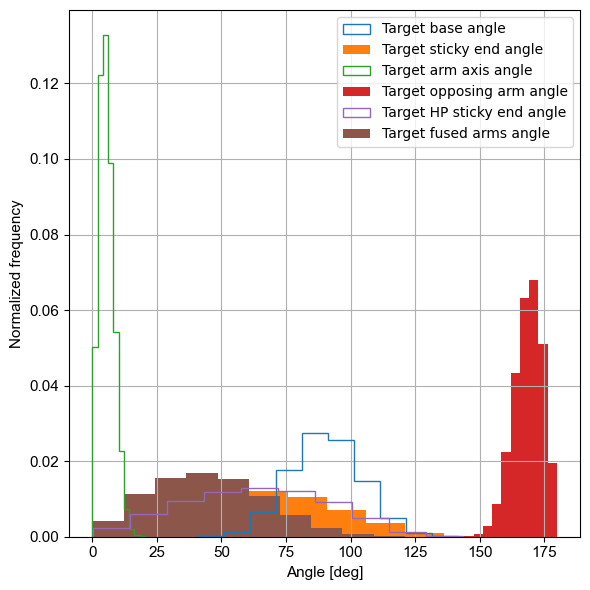

In [4]:
plt.figure(figsize=(6,6))
plt.hist(values_angle_base_target*180/np.pi,density=True,label="Target base angle",histtype="step")
plt.hist(values_angle_link_target*180/np.pi,density=True,label="Target sticky end angle",histtype="bar")
plt.hist(values_angle_arm_axis_target*180/np.pi,density=True,label="Target arm axis angle",histtype="step")
plt.hist(values_angle_oppa_target*180/np.pi,density=True,label="Target opposing arm angle",histtype="bar")
plt.hist(values_angle_link_HP_target*180/np.pi,density=True,label="Target HP sticky end angle",histtype="step")
plt.hist(values_angle_ds_fused_link_target*180/np.pi,density=True,label="Target fused arms angle",histtype="bar")


plt.legend()
plt.xlabel("Angle [deg]",fontname = "Arial",fontsize=11)
plt.ylabel("Normalized frequency",fontname = "Arial",fontsize=11)
plt.xticks(fontname = "Arial",fontsize=11)
plt.yticks(fontname = "Arial",fontsize=11)
plt.grid()
plt.tight_layout()

Text(0.02, 0.5, 'Normalised frequency')

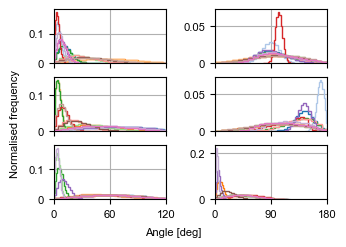

In [21]:

from matplotlib.ticker import FuncFormatter

fs = 8 

# Custom y-tick formatter: round to 2 decimals and strip trailing zeros/dot
def fmt_ytick(y, pos):
    s = f"{y:.2f}"                 # at most two visible decimals
    s = s.rstrip('0').rstrip('.')  # strip trailing zeros and any dangling dot
    return s

ytick_formatter = FuncFormatter(fmt_ytick)

datasets = {
    "Arm axis angle":        (values_angle_arm_axis_target_list[:13],      "tab:blue",   "step", 1.00),
    "Link angle":            (values_angle_link_target_list[:13],          "red",        "step",  0.75),
    "HP link angle":         (values_angle_link_HP_target_list[:13],       "tab:purple", "step", 1.00),
    "Base angle":            (values_angle_base_target_list[:13],          "tab:orange", "step",  0.75),
    "Opposing arm angle":    (values_angle_oppa_target_list[:13],          "tab:olive",  "step", 1.00),
    "Bound angle":           (values_angle_ds_fused_link_target_list[:13], "black",      "step",  0.75),
}

# Layout mapping: (row, col)
# Left column: Arm axis, Link, HP link
# Right column: Base, Opposing arm, Bound
layout_order = [
    ("Arm axis angle",      0, 0),
    ("Base angle",          0, 1),
    ("Link angle",          1, 0),
    ("Opposing arm angle",  1, 1),
    ("HP link angle",       2, 0),
    ("Bound angle",         2, 1),
]

# Figure size (twice as wide as original (3.5/2.54, 3.5/2.54))
width_in  =(8.5/2.54)# (8.5/2.54) #2 * (3.5/2.54)
height_in =  (6/2.54)#    (3.5/2.54)

fig, axes = plt.subplots(
    nrows=3, ncols=2,
    figsize=(width_in, height_in),
    sharex='col',                 # share x within each column
    constrained_layout=True
)
axes = np.asarray(axes)

colors_s = plt.cm.tab20.colors
for name, r, c in layout_order:
    vals, color, htype, alpha = datasets[name]
    #vals_deg = np.asarray(vals) * 180/np.pi
    #print(vals_deg)
    ax = axes[r, c]

    
    for i in range(len(vals)):
        hist_kwargs = dict(density=True, bins=20, color=colors_s[i], label=name)
        if htype == "step":
            ax.hist(vals[i]* 180/np.pi, histtype="step", **hist_kwargs)
            #print(vals)
            #ax.hist(vals[0],density=True,label="Target base angle",histtype="step")
    
    
        else:
            ax.hist(vals[i]* 180/np.pi, histtype="bar", alpha=alpha, **hist_kwargs)

    # Per-subplot legend
    #ax.legend(loc="upper right", frameon=False,
        #      prop={'family': 'Arial', 'size': fs-1})

    # Grid and y-tick formatter
    ax.grid(True)
    ax.yaxis.set_major_formatter(ytick_formatter)

    # Tick font sizes & family
    ax.tick_params(labelsize=fs)
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontname("Arial")

    # If axis labels are added later, enforce fs
    if ax.get_xlabel():
        ax.set_xlabel(ax.get_xlabel(), fontsize=fs, fontname="Arial")
    if ax.get_ylabel():
        ax.set_ylabel(ax.get_ylabel(), fontsize=fs, fontname="Arial")

# --- Column-specific x ticks and limits ---
# Left column: [0, 30, 60] with xlim(0, 60)
for r in range(3):
    axes[r, 0].set_xticks([0, 60, 120])
    axes[r, 0].set_xlim(0, 120)

# Right column: [0, 90, 180] with xlim(0, 180)
for r in range(3):
    axes[r, 1].set_xticks([0, 90, 180])
    axes[r, 1].set_xlim(0, 180)

# Shared labels (fs enforced)
fig.supxlabel("Angle [deg]", fontsize=fs, fontname="Arial")
fig.supylabel("Normalised frequency", fontsize=fs, fontname="Arial")

#plt.show()
#plt.savefig("ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/val_target_angles_1.pdf",format="pdf",bbox_inches="tight")


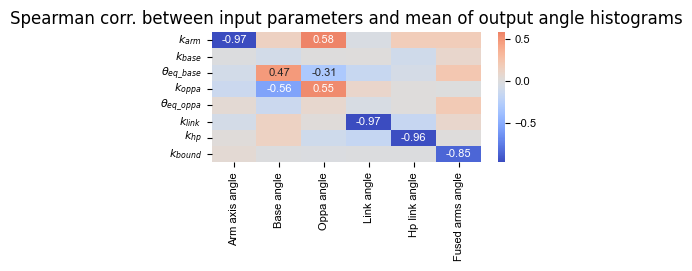

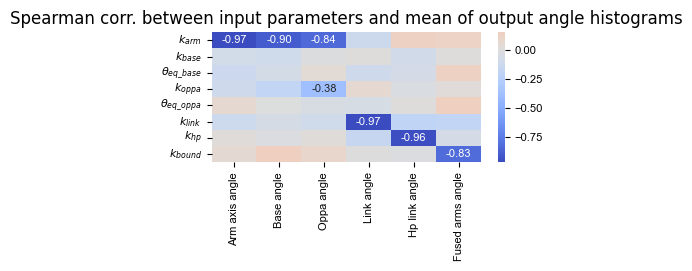

In [13]:


angle_names=["Base angle","Link angle","Arm axis angle","Oppa angle","Hp link angle","Fused arms angle"]
param_names=["k_angle_ds_base",
            "k_angle_ds_arm",
            "k_angle_ds_oppa",
            "k_angle_ss_link",
            "k_angle_ds_fused_link",
            "k_angle_ds_hp",
            "theta_base_x",
            "theta_oppa_x"]

param_names=[r"$k_{base}$",
            r"$k_{arm}$",
            r"$k_{oppa}$",
            r"$k_{link}$",
            r"$k_{bound}$",
            r"$k_{hp}$",
            r"$\theta_{eq\_base}$",
            r"$\theta_{eq\_oppa}$"]

# Random input parameters
#use idices of selected parameters
#rd_param_df= pd.DataFrame(rd_param_array[:], columns=param_names)
#use values of selected parameters
rd_param_df= pd.DataFrame(rd_param_values_array[:], columns=param_names)



values_angle_base_target_list_mean=np.mean(values_angle_base_target_list,axis=1)
values_angle_link_target_list_mean=np.mean(values_angle_link_target_list,axis=1)
values_angle_arm_axis_target_list_mean=np.mean(values_angle_arm_axis_target_list,axis=1)
values_angle_oppa_target_list_mean=np.mean(values_angle_oppa_target_list,axis=1)
values_angle_link_HP_target_list_mean=np.mean(values_angle_link_HP_target_list,axis=1)
values_angle_ds_fused_link_target_list_mean=np.mean(values_angle_ds_fused_link_target_list,axis=1)



all_values_angle_target_mean={"Base angle":values_angle_base_target_list_mean,
                              "Link angle":values_angle_link_target_list_mean,
                              "Arm axis angle":values_angle_arm_axis_target_list_mean,
                              "Oppa angle":values_angle_oppa_target_list_mean,
                              "Hp link angle":values_angle_link_HP_target_list_mean,
                              "Fused arms angle":values_angle_ds_fused_link_target_list_mean}



values_angle_base_target_list_std=np.std(values_angle_base_target_list,axis=1)
values_angle_link_target_list_std=np.std(values_angle_link_target_list,axis=1)
values_angle_arm_axis_target_list_std=np.std(values_angle_arm_axis_target_list,axis=1)
values_angle_oppa_target_list_std=np.std(values_angle_oppa_target_list,axis=1)
values_angle_link_HP_target_list_std=np.std(values_angle_link_HP_target_list,axis=1)
values_angle_ds_fused_link_target_list_std=np.std(values_angle_ds_fused_link_target_list,axis=1)

all_values_angle_target_std={"Base angle":values_angle_base_target_list_std,
                             "Link angle":values_angle_link_target_list_std,
                             "Arm axis angle":values_angle_arm_axis_target_list_std,
                             "Oppa angle":values_angle_oppa_target_list_std,
                             "Hp link angle":values_angle_link_HP_target_list_std,
                             "Fused arms angle":values_angle_ds_fused_link_target_list_std}

# Simulated output histograms (e.g., mean angle values from histograms)
order_1=["Arm axis angle","Base angle","Oppa angle","Link angle","Hp link angle","Fused arms angle"]

order_params_1=[r"$k_{arm}$",r"$k_{base}$",r"$\theta_{eq\_base}$",r"$k_{oppa}$",r"$\theta_{eq\_oppa}$",r"$k_{link}$",r"$k_{hp}$",r"$k_{bound}$",]

all_values_angle_target_mean_df= pd.DataFrame(all_values_angle_target_mean)[order_1]
all_values_angle_target_std_df= pd.DataFrame(all_values_angle_target_std)[order_1]

# Combine into one DataFrame
data = pd.concat([rd_param_df[order_params_1], all_values_angle_target_mean_df], axis=1)

# Compute Spearman correlation matrix
corr_matrix = data.corr(method='spearman')

# Create annotation matrix with values only above the threshold
annot_map =corr_matrix.map(lambda x: f"{x:.2f}" if abs(x) > 0.3 else "") #corr_matrix.map(lambda x: f"{x:.2f}" if abs(x) > 0.3 else "")

# Visualize the correlation between input parameters and output histograms
plt.figure(figsize=(11/2.54, 8/2.54))  #(5, 5)
cax=sns.heatmap(corr_matrix.loc[order_params_1, order_1], annot=annot_map.loc[order_params_1, order_1], cmap='coolwarm', center=0, fmt='',annot_kws={"size": 8, "fontname": "Arial"})
plt.title('Spearman corr. between input parameters and mean of output angle histograms')
plt.tight_layout()
plt.yticks(rotation=0)
plt.xticks(fontname = "Arial",fontsize=8)
plt.yticks(fontname= "Arial",fontsize=8)
cbar = cax.collections[0].colorbar
cbar.ax.tick_params(labelsize=8,labelfontfamily="Arial")
#plt.show()
save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/param_cor_mean_1.pdf"
#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

# Combine into one DataFrame
data = pd.concat([rd_param_df, all_values_angle_target_std_df], axis=1)

# Compute Spearman correlation matrix
corr_matrix = data.corr(method='spearman')

# Create annotation matrix with values only above the threshold
annot_map =corr_matrix.map(lambda x: f"{x:.2f}" if abs(x) > 0.3 else "") #corr_matrix.map(lambda x: f"{x:.2f}" if abs(x) > 0.3 else "")

# Visualize the correlation between input parameters and output histograms
fig=plt.figure(figsize=(11/2.54, 8/2.54))  #(5, 5)
cax=sns.heatmap(corr_matrix.loc[order_params_1, order_1], annot=annot_map.loc[order_params_1, order_1], cmap='coolwarm', center=0, fmt='',annot_kws={"size": 8, "fontname": "Arial"})
plt.title('Spearman corr. between input parameters and mean of output angle histograms')
plt.tight_layout()
plt.yticks(rotation=0)
plt.xticks(fontname = "Arial",fontsize=8)
plt.yticks(fontname= "Arial",fontsize=8)
cbar = cax.collections[0].colorbar
cbar.ax.tick_params(labelsize=8,labelfontfamily="Arial")
#plt.show()
save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/param_cor_std_1.pdf"
#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

# Iterate optimization over validation targets

In [ ]:
#use botorch implementation 
#initialize GP model, train on input and predict next params
def apply_gp_bo_1(x_rs,x_train_rs,x,f_train_rs,seed,dim_x,dim_y,num_restarts,raw_samples,scaler_x):
    #x_rs: full rescaled parameter space  -> no actual rescaling needed with internal rescaling by botorch
    #x_train_rs: rescaled training values -> no actual rescaling needed with internal rescaling by botorch
    #x: full non-rescaled parameter space -> only needed to get bounds
    #initialize and train GP model

    #set random seed for torch and numpy, each round gets different seed based on number of rounds
    torch.manual_seed(seed+len(f_train_rs))
    np.random.seed(seed+len(f_train_rs))

    #fit scaler on full range of values
    scaler_x1=scaler_x()
    scaler_x1.fit(x) 
    x=scaler_x1.transform(x)
    #print(x)
    #minimum and maximum values for bounds
    min_bounds = np.min(x, axis=0)
    max_bounds = np.max(x, axis=0)
    bounds = np.vstack((min_bounds, max_bounds))
    #print(bounds)
    bounds = torch.from_numpy(bounds)
    #print(x_train_rs,f_train_rs)

    #x and f as arrays
    x_train_rs=np.array(x_train_rs)
    f_train_rs=np.array(f_train_rs).reshape(-1,1)

    #option to scale input before botorch 
    x_train_rs=scaler_x1.transform(x_train_rs)
    #print(x_train_rs,f_train_rs)

    #x and f as torch tensor
    x_train_rs=torch.from_numpy(x_train_rs)
    f_train_rs=torch.from_numpy(f_train_rs)
    
    #print(x_train_rs.shape,f_train_rs.shape)
    #option to specify noise
    #train_fvar = torch.zeros_like(f_train_rs)  # Zero noise
    #likelihood = FixedNoiseGaussianLikelihood(noise=train_fvar)
    #gp=SingleTaskGP(train_X=x_train_rs,train_Y=f_train_rs,**params_SingleTaskGP_dict)
    gp=SingleTaskGP(train_X=x_train_rs,train_Y=f_train_rs,input_transform=Normalize(d=dim_x),outcome_transform=Standardize(m=dim_y))
    

    mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
    fit_gpytorch_mll(mll)

    logEI = LogExpectedImprovement(model=gp, best_f=f_train_rs.max())
    #ei = ExpectedImprovement(model=gp, best_f=f_train_rs.max())
    ucb =UpperConfidenceBound(gp, beta=1)

    candidate, acq_value = optimize_acqf(ucb, bounds=bounds, q=1, num_restarts=num_restarts, raw_samples=raw_samples)

    x_rs_next=candidate.detach().numpy()[0]
    #print(x_rs_next)
    #apply inverse scaling transform
    if dim_x==1:
        x_next=scaler_x1.inverse_transform(x_rs_next.reshape(-1, 1)).flatten()
    else:
        x_next=scaler_x1.inverse_transform(x_rs_next)
    #x_next=x_rs_next
    print(x_rs_next,x_next)
    gpr=None
    
    return x_next, x_next, gpr




In [ ]:
#for GP parameter values need to be in other range, for instance [0,5], apply scaler to parameter lists
def rescaled_params_df(df):
    scalers = []
    scaled_values = []

    for values in df['Param values']:
        scaler = MinMaxScaler(feature_range=(0, 5))
        scaled = scaler.fit_transform(np.asarray(values*10**20).reshape(-1, 1)).flatten()
        scalers.append(scaler)
        scaled_values.append(scaled)

    df['Scalers'] = scalers
    df['Rs param values'] = scaled_values
    
    return df

#generate linearly scaled rs values, independent of actual parameter scaling
def rescaled_params_2_df(df):
    scalers = []
    scaled_values = []

    for values in df['Param values']:
        scaler = MinMaxScaler(feature_range=(0, 5))
        values_lin=np.linspace(0,5,len(values))
        scaled = scaler.fit_transform(values_lin.reshape(-1, 1)).flatten()
        scalers.append(scaler)
        scaled_values.append(scaled)

    df['Scalers'] = scalers
    df['Rs param values'] = scaled_values
    
    return df

#place holder rescaling
def rescaled_params_no_sc_df(df):
    scalers = []
    scaled_values = []

    for values in df['Param values']:
        scaler = FunctionTransformer(func=None) #MinMaxScaler(feature_range=(0, 5))
        scaled = scaler.fit_transform(np.asarray(values).reshape(-1, 1)).flatten()
        scalers.append(scaler)
        scaled_values.append(scaled)

    df['Scalers'] = scalers
    df['Rs param values'] = scaled_values
    
    return df


def scale_by_inverse_min(X):
    min_vals = np.min(X, axis=0)
    return X * (1 / min_vals)

#sklearn scaler struggles with small values, use simple implementaion generated with Copilot
class MinMaxScaler2:
    def __init__(self):
        self.data_min = None
        self.data_max = None

    def fit(self, data):
        """
        Compute the minimum and maximum values for scaling.

        Parameters:
        data (numpy.ndarray): The input data to be scaled.
        """
        self.data_min = np.min(data, axis=0)
        self.data_max = np.max(data, axis=0)

    def transform(self, data):
        """
        Scale the data to the range [0, 1].

        Parameters:
        data (numpy.ndarray): The input data to be scaled.

        Returns:
        numpy.ndarray: The scaled data.
        """
        if self.data_min is None or self.data_max is None:
            raise ValueError("The scaler has not been fitted yet.")
        scaled_data = (data - self.data_min) / (self.data_max - self.data_min)
        return scaled_data

    def inverse_transform(self, scaled_data):
        """
        Reverse the scaling of the data.

        Parameters:
        scaled_data (numpy.ndarray): The scaled data to be reverted.

        Returns:
        numpy.ndarray: The original data.
        """
        if self.data_min is None or self.data_max is None:
            raise ValueError("The scaler has not been fitted yet.")
        original_data = scaled_data * (self.data_max - self.data_min) + self.data_min
        return original_data
        
#apply MinMaxScaler2 to data
def rescaled_params_df_MinMaxScaler2(df):
    scalers = []
    scaled_values = []

    for values in df['Param values']:
        scaler = MinMaxScaler2()
        scaler.fit(np.asarray(values).reshape(-1, 1))
        scaled = scaler.transform(np.asarray(values).reshape(-1, 1)).flatten()
        scalers.append(scaler)
        scaled_values.append(scaled)

    df['Scalers'] = scalers
    df['Rs param values'] = scaled_values
    
    return df

In [ ]:
%%capture 
#use split optimisation aa+(ba+oa &la)+hp+bm
#load targets
base_angle_distr_target_list=np.load('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_base_angle_distr_target.npy')
link_angle_distr_target_list=np.load('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_link_angle_distr_target.npy')
arm_axis_angle_distr_target_list=np.load('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_arm_axis_angle_distr_target.npy')
oppa_angle_distr_target_list=np.load('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_oppa_angle_distr_target.npy')
link_HP_angle_distr_target_list=np.load('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_link_HP_angle_distr_target.npy')
angle_ds_fused_link_distr_target_list=np.load('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_angle_ds_fused_link_distr_target.npy')

values_angle_base_target_list=np.load('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_values_angle_base_target.npy')
values_angle_link_target_list=np.load('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_values_angle_link_target.npy')
values_angle_arm_axis_target_list=np.load('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_values_angle_arm_axis_target.npy')
values_angle_oppa_target_list=np.load('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_values_angle_oppa_target.npy')
values_angle_link_HP_target_list=np.load('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_values_angle_link_HP_target.npy')
values_angle_ds_fused_link_target_list=np.load('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_values_angle_ds_fused_link_target.npy')



for i in [0,1,2,3,4,5,6,7,8,9,10,11,12]:
    folder_n="/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_validation_bay_opt_sims_2_v1/D_target_id_"+str(i)+"/"
    
    
    sel_val_target=i
    
    base_angle_distr_target=base_angle_distr_target_list[sel_val_target]
    link_angle_distr_target=link_angle_distr_target_list[sel_val_target]
    arm_axis_angle_distr_target=arm_axis_angle_distr_target_list[sel_val_target]
    oppa_angle_distr_target=oppa_angle_distr_target_list[sel_val_target]
    link_HP_angle_distr_target=link_HP_angle_distr_target_list[sel_val_target]
    angle_ds_fused_link_distr_target=angle_ds_fused_link_distr_target_list[sel_val_target]
    
    values_angle_base_target=values_angle_base_target_list[sel_val_target]
    values_angle_link_target=values_angle_link_target_list[sel_val_target]
    values_angle_arm_axis_target=values_angle_arm_axis_target_list[sel_val_target]
    values_angle_oppa_target=values_angle_oppa_target_list[sel_val_target]
    values_angle_link_HP_target=values_angle_link_HP_target_list[sel_val_target]
    values_angle_ds_fused_link_target=values_angle_ds_fused_link_target_list[sel_val_target]
    
    
    list_values_target_angles_1=[values_angle_base_target,values_angle_link_target,values_angle_arm_axis_target,values_angle_oppa_target,values_angle_link_HP_target,values_angle_ds_fused_link_target]
    
    
    ##################################################
    ##################################################
    ################## aa angle ######################
    ##################################################
    ##################################################

    #copy of sim params
    run_sim_1_input_1=run_sim_1_input.copy()
    
    #specify which parameters are to be optimised over which range
    var_params_1={"Param names":["k_angle_ds_arm"],
                             
                "Param values":[k_angle_ds_arm_range],
                
                "Set of indep params":[0],
               "Index init guess":[[0,3]] #[1,8]
               }
    
    df_var_params_1=pd.DataFrame(var_params_1)

    
    
    #placeholder scaler on real values
    df_var_params_1 = rescaled_params_no_sc_df(df_var_params_1)

    ########################
    ########################

    #specify evaluation and Bayesian opt parameters for each independent set of parameters
    #every independent parameter set needs own dictionaries for GP and eval, as parameters need to be updated independently later
    
    
    GP_params_1={"x_rs":[[0]],"x_train_rs":[[0]],"x":[[0]],"f_train_rs":[[0]],"seed":1,"dim_x":1,"dim_y":1,"num_restarts":100,"raw_samples":1000,"scaler_x":MinMaxScaler2}
    
    
    Eval_params_1={"folder":None,"names_sim_repeat":None,"t_skip":300,"t_lim":None,"t_step":1,
                 "arm_axis_angle_distr_target":arm_axis_angle_distr_target}
    
    eval_opt_param_set_1={"Set of indep params":[0],
                          "Eval fct": [eval_sim_c1_1_aa],
                          "Eval params":[Eval_params_1],
                          "Scaler": [FunctionTransformer(func=None)],
                          "GP": [apply_gp_bo_1],
                          "GP params": [GP_params_1]}
    
    df_eval_opt_param_set_1=pd.DataFrame(eval_opt_param_set_1)

    ###########################
    ###########################

    #run optimization
    df_t1,gpr_1=run_gp_11(df_run_sim=run_sim_1_input_1,
                  df_var_params=df_var_params_1,
                  fct_sim=run_sim_3,
                  df_eval_opt_param_set=df_eval_opt_param_set_1,        
                  sim_folder=folder_n+"D_aa_opt_1/",
                  sim_name="sim_aa_opt_1_",
                  file_name_sim_params="params_aa_opt_1", #None, #"params_aa_opt_1", 
                  sim_repeats=5,
                  iterations=20,
                  print_sim_config=False,
                  load_existing_init_sims=False,
                  load_existing_opt_sims=False)

    #############################
    #############################

    #create dictionary with updated parameters
    dict_opt_params_step_1={}
    dict_opt_rs_params_step_1={}
    
    for index, row in df_t1.iterrows():
        id_max=np.argmax(row["f train"])
        print("max fitness:",id_max,np.max(row["f train"]))
        opt_params_names=row["Param names in set"]
        opt_params_names_rs=[ e+"_rs" for e in opt_params_names]
        opt_params=row["x train"][id_max]
        opt_params_rs=row["x train rs"][id_max]
        
        for key, value in zip(opt_params_names,opt_params):
            dict_opt_params_step_1[key] = value
        for key, value in zip(opt_params_names_rs,opt_params_rs):
            dict_opt_rs_params_step_1[key] = value    
            
        #print("param set:",row["Set of indep params"],row["x train rs"][id_max])
        #print("param set:",row["Set of indep params"],row["x train"][id_max])

    ##################################################
    ##################################################
    ############### ba oa la angle ###################
    ##################################################
    ##################################################

    #copy of sim params
    run_sim_1_input_2=run_sim_1_input.copy()
    
    #update parameters optimized in previous step
    run_sim_1_input_2.update(dict_opt_params_step_1)
    
    #specify which parameters are to be optimised over which range
    var_params_2={"Param names":["k_angle_ds_base",
                              "k_angle_ds_oppa",
                              "k_angle_ss_link",
                              "theta_base_x",
                              "theta_oppa_x"],
                             
                "Param values":[k_angle_ds_base_range,
                               k_angle_ds_oppa_range,
                               k_angle_ss_link_range,
                               theta_base_x_range,
                               theta_oppa_x_range],
                
                "Set of indep params":[0,
                                     0,
                                     1,
                                     0,
                                     0],
               "Index init guess":[[0,0,3,3,0,0,3,3,0,0,3,3,0,0,3,3],
                                   [0,3,0,3,0,3,0,3,0,3,0,3,0,3,0,3],
                                   [0,3,0,3,0,3,0,3,0,3,0,3,0,3,0,3],
                                   [0,0,0,0,3,3,3,3,0,0,0,0,3,3,3,3],
                                   [0,0,0,0,0,0,0,0,3,3,3,3,3,3,3,3],
                                  ]
               }
    
    '''[1,1,8,8,1,1,8,8,1,1,8,8,1,1,8,8],
                                   [1,8,1,8,1,8,1,8,1,8,1,8,1,8,1,8],
                                   [1,8,1,8,1,8,1,8,1,8,1,8,1,8,1,8],
                                   [1,1,1,1,8,8,8,8,1,1,1,1,8,8,8,8],
                                   [1,1,1,1,1,1,1,1,8,8,8,8,8,8,8,8],
                                  ]'''
    
    df_var_params_2=pd.DataFrame(var_params_2)
    
    
    
    #Std scaler on real values
    #df_var_params_2 = rescaled_params_df(df_var_params_2)
    
    #placeholder scaler on real values
    df_var_params_2 = rescaled_params_no_sc_df(df_var_params_2)

    ###########################
    ###########################

    #specify evaluation and Bayesian opt parameters for each independent set of parameters
    #every independent parameter set needs own dictionaries for GP and eval, as parameters need to be updated independently later
    GP_params_2_0={"x_rs":[[0]],"x_train_rs":[[0]],"x":[[0]],"f_train_rs":[[0]],"seed":1,"dim_x":4,"dim_y":1,"num_restarts":1000,"raw_samples":10000,"scaler_x":MinMaxScaler2}
    GP_params_2_1={"x_rs":[[0]],"x_train_rs":[[0]],"x":[[0]],"f_train_rs":[[0]],"seed":1,"dim_x":1,"dim_y":1,"num_restarts":1000,"raw_samples":10000,"scaler_x":MinMaxScaler2}
    
    
    Eval_params_2_0={"folder":None,"names_sim_repeat":None,"t_skip":300,"t_lim":None,"t_step":1,
                 "base_angle_distr_target":base_angle_distr_target,
                 "oppa_angle_distr_target":oppa_angle_distr_target}
    
    Eval_params_2_1={"folder":None,"names_sim_repeat":None,"t_skip":300,"t_lim":None,"t_step":1,
                 "link_angle_distr_target":link_angle_distr_target}
    
    eval_opt_param_set_2={"Set of indep params":[0,
                                                 1],
                          "Eval fct": [eval_sim_c1_2_ba_oa,
                                       eval_sim_c1_1_la],
                          "Eval params":[Eval_params_2_0,
                                         Eval_params_2_1],
                          "Scaler": [FunctionTransformer(func=None),
                                     FunctionTransformer(func=None)],
                          "GP": [apply_gp_bo_1,
                                 apply_gp_bo_1],
                          "GP params": [GP_params_2_0,
                                        GP_params_2_1]}
    
    df_eval_opt_param_set_2=pd.DataFrame(eval_opt_param_set_2)

    ##########################
    ##########################

    #run optimization
    df_t2,gpr_2=run_gp_11(df_run_sim=run_sim_1_input_2,
                  df_var_params=df_var_params_2,
                  fct_sim=run_sim_3,
                  df_eval_opt_param_set=df_eval_opt_param_set_2,
                  sim_folder=folder_n+"D_ba_oa_la_opt_1/",
                  sim_name="sim_ba_oa_la_opt_1_",
                  file_name_sim_params="params_ba_oa_la_opt_1", #None, #"params_ba_oa_la_opt_1", 
                  sim_repeats=5,
                  iterations=120,
                  print_sim_config=False,
                  load_existing_init_sims=False,
                  load_existing_opt_sims=False)

    ##########################
    ##########################

    #create dictionary with updated parameters
    dict_opt_params_step_2={}
    dict_opt_rs_params_step_2={}
    
    for index, row in df_t2.iterrows():
        id_max=np.argmax(row["f train"])
        print("max fitness:",id_max,np.max(row["f train"]))
        opt_params_names=row["Param names in set"]
        opt_params_names_rs=[ e+"_rs" for e in opt_params_names]
        opt_params=row["x train"][id_max]
        opt_params_rs=row["x train rs"][id_max]
        
        for key, value in zip(opt_params_names,opt_params):
            dict_opt_params_step_2[key] = value
        for key, value in zip(opt_params_names_rs,opt_params_rs):
            dict_opt_rs_params_step_2[key] = value    
            
        #print("param set:",row["Set of indep params"],row["x train rs"][id_max])
        #print("param set:",row["Set of indep params"],row["x train"][id_max])



    ##################################################
    ##################################################
    ################## hp angle ######################
    ##################################################
    ##################################################

    #copy of sim params
    run_sim_1_input_3=run_sim_1_input.copy()
    
    #update parameters optimized in previous step
    run_sim_1_input_3.update(dict_opt_params_step_1)
    run_sim_1_input_3.update(dict_opt_params_step_2)
    
    #need HP template
    run_sim_1_input_3["use_x_c1_HP_template"]=True
    
    #specify which parameters are to be optimised over which range
    var_params_3={"Param names":["k_angle_ds_hp"],
                             
                "Param values":[k_angle_ds_hp_range],
                
                "Set of indep params":[0],
               "Index init guess":[[0,3]]  #[1,8]
               }
    
    df_var_params_3=pd.DataFrame(var_params_3)
    
    
    #Std scaler on real values
    #df_var_params_3 = rescaled_params_df(df_var_params_3)
    
    #placeholder scaler on real values
    df_var_params_3 = rescaled_params_no_sc_df(df_var_params_3)

    ###############################
    ###############################
    
    #specify evaluation and Bayesian opt parameters for each independent set of parameters
    #every independent parameter set needs own dictionaries for GP and eval, as parameters need to be updated independently later
    GP_params_3={"x_rs":[[0]],"x_train_rs":[[0]],"x":[[0]],"f_train_rs":[[0]],"seed":1,"dim_x":1,"dim_y":1,"num_restarts":100,"raw_samples":1000,"scaler_x":MinMaxScaler2}
    
    
    Eval_params_3={"folder":None,"names_sim_repeat":None,"t_skip":300,"t_lim":None,"t_step":1,
                 "link_HP_angle_distr_target":link_HP_angle_distr_target}
    
    eval_opt_param_set_3={"Set of indep params":[0],
                          "Eval fct": [eval_sim_c1_1_hp],
                          "Eval params":[Eval_params_3],
                          "Scaler": [StandardScaler()],
                          "GP": [apply_gp_bo_1],
                          "GP params": [GP_params_3]}
    
    df_eval_opt_param_set_3=pd.DataFrame(eval_opt_param_set_3)

    ###############################
    ###############################

    #run optimization
    df_t3,gpr_3=run_gp_11(df_run_sim=run_sim_1_input_3,
                  df_var_params=df_var_params_3,
                  fct_sim=run_sim_3,
                  df_eval_opt_param_set=df_eval_opt_param_set_3,
                  sim_folder=folder_n+"D_hp_opt_1/",
                  sim_name="sim_hp_opt_1_",
                  file_name_sim_params="params_hp_opt_1", #None, #"params_hp_opt_1", 
                  sim_repeats=5,
                  iterations=20,
                  print_sim_config=False,
                  load_existing_init_sims=False,
                  load_existing_opt_sims=False)

    ###############################
    ###############################

    #create dictionary with updated parameters
    dict_opt_params_step_3={}
    dict_opt_rs_params_step_3={}
    
    for index, row in df_t3.iterrows():
        id_max=np.argmax(row["f train"])
        print("max fitness:",id_max,np.max(row["f train"]))
        opt_params_names=row["Param names in set"]
        opt_params_names_rs=[ e+"_rs" for e in opt_params_names]
        opt_params=row["x train"][id_max]
        opt_params_rs=row["x train rs"][id_max]
        
        for key, value in zip(opt_params_names,opt_params):
            dict_opt_params_step_3[key] = value
        for key, value in zip(opt_params_names_rs,opt_params_rs):
            dict_opt_rs_params_step_3[key] = value    
            
        #print("param set:",row["Set of indep params"],row["x train rs"][id_max])
        #print("param set:",row["Set of indep params"],row["x train"][id_max])


    ##################################################
    ##################################################
    ################## bm angle ######################
    ##################################################
    ##################################################

        #copy of sim params
    run_sim_1_input_4=run_sim_1_input.copy()
    
    #update parameters optimized in previous step
    run_sim_1_input_4.update(dict_opt_params_step_1)
    run_sim_1_input_4.update(dict_opt_params_step_2)
    run_sim_1_input_4.update(dict_opt_params_step_3)
    
    #load state with two fused motifs
    run_sim_1_input_4["checkpoint_path"]="/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/two_fused_conrad_x_motifs_checkpoint/"
    
    #specify which parameters are to be optimised over which range
    var_params_4={"Param names":["k_angle_ds_fused_link"],
                             
                "Param values":[k_angle_ds_fused_link_range],
                
                "Set of indep params":[0],
               "Index init guess":[[0,3]] #[1,8]
               }
    
    
    df_var_params_4=pd.DataFrame(var_params_4)
    
    
    #Std scaler on real values
    #df_var_params_4 = rescaled_params_df(df_var_params_4)
    
    #Std scaler on placeholder linearly scaled values
    #df_var_params_4 = rescaled_params_2_df(df_var_params_4)
    
    #placeholder scaler on real values
    df_var_params_4 = rescaled_params_no_sc_df(df_var_params_4)

    #############################
    #############################

    #specify evaluation and Bayesian opt parameters for each independent set of parameters
    #every independent parameter set needs own dictionaries for GP and eval, as parameters need to be updated independently later
    GP_params_4={"x_rs":[[0]],"x_train_rs":[[0]],"x":[[0]],"f_train_rs":[[0]],"seed":1,"dim_x":1,"dim_y":1,"num_restarts":100,"raw_samples":1000,"scaler_x":MinMaxScaler2}
    
    
    Eval_params_4={"folder":None,"names_sim_repeat":None,"t_skip":300,"t_lim":None,"t_step":1,
                 "angle_ds_fused_link_distr_target":angle_ds_fused_link_distr_target}
    
    eval_opt_param_set_4={"Set of indep params":[0],
                          "Eval fct": [eval_sim_c1_1_bm],
                          "Eval params":[Eval_params_4],
                          "Scaler": [StandardScaler()],
                          "GP": [apply_gp_bo_1],
                          "GP params": [GP_params_4]}
    
    df_eval_opt_param_set_4=pd.DataFrame(eval_opt_param_set_4)
    df_eval_opt_param_set_4


    #############################
    #############################

    #run optimization
    df_t4,gpr_4=run_gp_11(df_run_sim=run_sim_1_input_4,
                  df_var_params=df_var_params_4,
                  fct_sim=run_sim_3,
                  df_eval_opt_param_set=df_eval_opt_param_set_4,
                  sim_folder=folder_n+"D_bm_opt_1/",
                  sim_name="sim_bm_opt_1_",
                  file_name_sim_params="params_bm_opt_1", #None, #"params_bm_opt_1", 
                  sim_repeats=5,
                  iterations=20,
                  print_sim_config=False,
                  load_existing_init_sims=False,
                  load_existing_opt_sims=False)

    #############################
    #############################

    #create dictionary with updated parameters
    dict_opt_params_step_4={}
    dict_opt_rs_params_step_4={}
    
    for index, row in df_t4.iterrows():
        id_max=np.argmax(row["f train"])
        print("max fitness:",id_max,np.max(row["f train"]))
        opt_params_names=row["Param names in set"]
        opt_params_names_rs=[ e+"_rs" for e in opt_params_names]
        opt_params=row["x train"][id_max]
        opt_params_rs=row["x train rs"][id_max]
        
        for key, value in zip(opt_params_names,opt_params):
            dict_opt_params_step_4[key] = value
        for key, value in zip(opt_params_names_rs,opt_params_rs):
            dict_opt_rs_params_step_4[key] = value    
            
        #print("param set:",row["Set of indep params"],row["x train rs"][id_max])
        #print("param set:",row["Set of indep params"],row["x train"][id_max])


    ########################
    ########################

    #create dictionary with all updated parameters
    dict_opt_params_all_steps={}
    dict_opt_rs_params_all_steps={}
    
    dict_opt_params_all_steps.update(dict_opt_params_step_1)
    dict_opt_params_all_steps.update(dict_opt_params_step_2)
    dict_opt_params_all_steps.update(dict_opt_params_step_3)
    dict_opt_params_all_steps.update(dict_opt_params_step_4)
    
    dict_opt_rs_params_all_steps.update(dict_opt_rs_params_step_1)
    dict_opt_rs_params_all_steps.update(dict_opt_rs_params_step_2)
    dict_opt_rs_params_all_steps.update(dict_opt_rs_params_step_3)
    dict_opt_rs_params_all_steps.update(dict_opt_rs_params_step_4)

    
    # save optimal paramters 
    save_name_n1=folder_n+'optimal_params_1.pkl'
    with open(save_name_n1, 'wb') as file:
        pickle.dump(dict_opt_params_all_steps, file)
        
    save_name_n2=folder_n+'optimal_rs_params_1.pkl'   
    with open(save_name_n2, 'wb') as file:
        pickle.dump(dict_opt_rs_params_all_steps, file)

    ##################################################
    ##################################################
    ################## opt sim ######################
    ##################################################
    ##################################################
    
   load_name_n1=folder_n+'optimal_params_1.pkl'
    with open(load_name_n1, 'rb') as file:
        dict_opt_params_all_steps = pickle.load(file)
      
    #copy of sim params
    run_sim_1_input_opt_1=run_sim_1_input.copy()
    
    #update parameters optimized in previous step
    run_sim_1_input_opt_1.update(dict_opt_params_all_steps)


    run_sim_1_input_opt_1["folder"]=folder_n+"D_opt_sim_1/"
    run_sim_1_input_opt_1["name"]="x_opt_test_1_"
    run_sim_1_input_opt_1["add_num_1"]=0

    #run multiple copys of sim in parallel
    gen_sim_list=[]
    gen_sim_param_list=[]
    
    for i in range(5):
        gen_sim_list.append(run_sim_3)
        run_sim_1_input_c=run_sim_1_input_opt_1.copy()
        run_sim_1_input_c["add_num_1"]=i
        gen_sim_param_list.append(run_sim_1_input_c)
        
    run_p_dict(gen_sim_list,gen_sim_param_list)
    
    ######################
    ######################

    #copy of sim params
    run_sim_1_input_opt_2=run_sim_1_input.copy()
    
    #update parameters optimized in previous step
    run_sim_1_input_opt_2.update(dict_opt_params_all_steps)

    run_sim_1_input_opt_2["folder"]=folder_n+"D_opt_sim_1/"
    run_sim_1_input_opt_2["name"]="x_opt_test_hp_1_"
    run_sim_1_input_opt_2["add_num_1"]=0
    run_sim_1_input_opt_2["use_x_c1_HP_template"]=True
    #run multiple copys of sim in parallel
    gen_sim_list=[]
    gen_sim_param_list=[]
    
    for i in range(5):
        gen_sim_list.append(run_sim_3)
        run_sim_1_input_c=run_sim_1_input_opt_2.copy()
        run_sim_1_input_c["add_num_1"]=i
        gen_sim_param_list.append(run_sim_1_input_c)
        
    run_p_dict(gen_sim_list,gen_sim_param_list)

    ######################
    ######################
    
    #copy of sim params
    run_sim_1_input_opt_3=run_sim_1_input.copy()
    
    #update parameters optimized in previous step
    run_sim_1_input_opt_3.update(dict_opt_params_all_steps)

    run_sim_1_input_opt_3["folder"]=folder_n+"D_opt_sim_1/"
    run_sim_1_input_opt_3["name"]="x_opt_test_ba_1_"
    run_sim_1_input_opt_3["add_num_1"]=0
    run_sim_1_input_opt_3["checkpoint_path"]="/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/two_fused_conrad_x_motifs_checkpoint/"

    #run multiple copys of sim in parallel
    gen_sim_list=[]
    gen_sim_param_list=[]
    
    for i in range(5):
        gen_sim_list.append(run_sim_3)
        run_sim_1_input_c=run_sim_1_input_opt_3.copy()
        run_sim_1_input_c["add_num_1"]=i
        gen_sim_param_list.append(run_sim_1_input_c)
        
    run_p_dict(gen_sim_list,gen_sim_param_list)


In [ ]:
%%capture 
#use combined optimisation (aa+ba+oa &la)+hp+bm

#load targets
base_angle_distr_target_list=np.load('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_base_angle_distr_target.npy')
link_angle_distr_target_list=np.load('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_link_angle_distr_target.npy')
arm_axis_angle_distr_target_list=np.load('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_arm_axis_angle_distr_target.npy')
oppa_angle_distr_target_list=np.load('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_oppa_angle_distr_target.npy')
link_HP_angle_distr_target_list=np.load('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_link_HP_angle_distr_target.npy')
angle_ds_fused_link_distr_target_list=np.load('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_angle_ds_fused_link_distr_target.npy')

values_angle_base_target_list=np.load('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_values_angle_base_target.npy')
values_angle_link_target_list=np.load('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_values_angle_link_target.npy')
values_angle_arm_axis_target_list=np.load('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_values_angle_arm_axis_target.npy')
values_angle_oppa_target_list=np.load('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_values_angle_oppa_target.npy')
values_angle_link_HP_target_list=np.load('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_values_angle_link_HP_target.npy')
values_angle_ds_fused_link_target_list=np.load('/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/100_100_random_parameter_configs_2_values_angle_ds_fused_link_target.npy')



for i in [0,1,2,3,4,5,6,7,8,9,10,11,12]: #[2,3,4,5,6,7,8,9,10,11,12]
    folder_n="/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_validation_bay_opt_sims_2_v2/D_target_id_"+str(i)+"/"
    
    
    sel_val_target=i
    
    base_angle_distr_target=base_angle_distr_target_list[sel_val_target]
    link_angle_distr_target=link_angle_distr_target_list[sel_val_target]
    arm_axis_angle_distr_target=arm_axis_angle_distr_target_list[sel_val_target]
    oppa_angle_distr_target=oppa_angle_distr_target_list[sel_val_target]
    link_HP_angle_distr_target=link_HP_angle_distr_target_list[sel_val_target]
    angle_ds_fused_link_distr_target=angle_ds_fused_link_distr_target_list[sel_val_target]
    
    values_angle_base_target=values_angle_base_target_list[sel_val_target]
    values_angle_link_target=values_angle_link_target_list[sel_val_target]
    values_angle_arm_axis_target=values_angle_arm_axis_target_list[sel_val_target]
    values_angle_oppa_target=values_angle_oppa_target_list[sel_val_target]
    values_angle_link_HP_target=values_angle_link_HP_target_list[sel_val_target]
    values_angle_ds_fused_link_target=values_angle_ds_fused_link_target_list[sel_val_target]
    
    
    list_values_target_angles_1=[values_angle_base_target,values_angle_link_target,values_angle_arm_axis_target,values_angle_oppa_target,values_angle_link_HP_target,values_angle_ds_fused_link_target]
    
    
    

    ##################################################
    ##################################################
    ############### aa ba oa la angle ###################
    ##################################################
    ##################################################

    #for 5D problem, do initial simulations at edges of 5D-hypercube
    # Edge length
    edge_length = 3
    
    # Generate all combinations of 0 and 3 for 5 dimensions
    param_combs_5D = list(itertools.product([0, edge_length], repeat=5))
    param_combs_5D=np.array(param_combs_5D)
    
    param_combs_5D=np.transpose(param_combs_5D)
    #add 1D array for 1D Problem
    params_combs_1D = np.array([0]*16 + [3]*16) #.reshape(-1, 1)  # Reshape to column vector
    #print(params_combs_1D)
    #print(param_combs_5D)
    param_combs_5D_1D=np.vstack([param_combs_5D,params_combs_1D])
    
    param_combs_5D_1D_list=[]
    for i in range(len(param_combs_5D_1D)):
        param_combs_5D_1D_list_e=[]
        for j in range(len(param_combs_5D_1D[i])):
            param_combs_5D_1D_list_e.append(param_combs_5D_1D[i][j])
        param_combs_5D_1D_list.append(param_combs_5D_1D_list_e)

    #copy of sim params
    run_sim_1_input_2=run_sim_1_input.copy()
    
    #update parameters optimized in previous step
    #run_sim_1_input_2.update(dict_opt_params_step_1)
    
    #specify which parameters are to be optimised over which range
    var_params_2={"Param names":["k_angle_ds_arm",
                              "k_angle_ds_base",
                              "k_angle_ds_oppa",
                              "theta_base_x",
                              "theta_oppa_x",
                            "k_angle_ss_link"],
                             
                "Param values":[k_angle_ds_arm_range,
                               k_angle_ds_base_range,
                               k_angle_ds_oppa_range,
                               theta_base_x_range,
                               theta_oppa_x_range,
                               k_angle_ss_link_range],
                
                "Set of indep params":[0,
                                     0,
                                     0,
                                     0,
                                     0,
                                     1],
               "Index init guess":param_combs_5D_1D_list
               }

    
    df_var_params_2=pd.DataFrame(var_params_2)
    
    
    
    #Std scaler on real values
    #df_var_params_2 = rescaled_params_df(df_var_params_2)
    
    #placeholder scaler on real values
    df_var_params_2 = rescaled_params_no_sc_df(df_var_params_2)

    ###########################
    ###########################

    #specify evaluation and Bayesian opt parameters for each independent set of parameters
    #every independent parameter set needs own dictionaries for GP and eval, as parameters need to be updated independently later
    GP_params_2_0={"x_rs":[[0]],"x_train_rs":[[0]],"x":[[0]],"f_train_rs":[[0]],"seed":1,"dim_x":5,"dim_y":1,"num_restarts":1000,"raw_samples":10000,"scaler_x":MinMaxScaler2}
    GP_params_2_1={"x_rs":[[0]],"x_train_rs":[[0]],"x":[[0]],"f_train_rs":[[0]],"seed":1,"dim_x":1,"dim_y":1,"num_restarts":1000,"raw_samples":10000,"scaler_x":MinMaxScaler2}
    
    
    Eval_params_2_0={"folder":None,"names_sim_repeat":None,"t_skip":300,"t_lim":None,"t_step":1,
                 "arm_axis_angle_distr_target":arm_axis_angle_distr_target,
                 "base_angle_distr_target":base_angle_distr_target,
                 "oppa_angle_distr_target":oppa_angle_distr_target}
    
    Eval_params_2_1={"folder":None,"names_sim_repeat":None,"t_skip":300,"t_lim":None,"t_step":1,
                 "link_angle_distr_target":link_angle_distr_target}
    
    eval_opt_param_set_2={"Set of indep params":[0,
                                                 1],
                          "Eval fct": [eval_sim_c1_3_aa_ba_oa,
                                       eval_sim_c1_1_la],
                          "Eval params":[Eval_params_2_0,
                                         Eval_params_2_1],
                          "Scaler": [FunctionTransformer(func=None),
                                     FunctionTransformer(func=None)],
                          "GP": [apply_gp_bo_1,
                                 apply_gp_bo_1],
                          "GP params": [GP_params_2_0,
                                        GP_params_2_1]}
    
    df_eval_opt_param_set_2=pd.DataFrame(eval_opt_param_set_2)

    ##########################
    ##########################

    #run optimization
    df_t2,gpr_2=run_gp_11(df_run_sim=run_sim_1_input_2,
                  df_var_params=df_var_params_2,
                  fct_sim=run_sim_3,
                  df_eval_opt_param_set=df_eval_opt_param_set_2,
                  sim_folder=folder_n+"D_aa_ba_oa_la_opt_1/",
                  sim_name="sim_aa_ba_oa_la_opt_1_",
                  file_name_sim_params="params_aa_ba_oa_la_opt_1", #None, #"params_ba_oa_la_opt_1", 
                  sim_repeats=5,
                  iterations=120,
                  print_sim_config=False,
                  load_existing_init_sims=False,
                  load_existing_opt_sims=False)

    ##########################
    ##########################

    #create dictionary with updated parameters
    dict_opt_params_step_2={}
    dict_opt_rs_params_step_2={}
    
    for index, row in df_t2.iterrows():
        id_max=np.argmax(row["f train"])
        print("max fitness:",id_max,np.max(row["f train"]))
        opt_params_names=row["Param names in set"]
        opt_params_names_rs=[ e+"_rs" for e in opt_params_names]
        opt_params=row["x train"][id_max]
        opt_params_rs=row["x train rs"][id_max]
        
        for key, value in zip(opt_params_names,opt_params):
            dict_opt_params_step_2[key] = value
        for key, value in zip(opt_params_names_rs,opt_params_rs):
            dict_opt_rs_params_step_2[key] = value    
            
        #print("param set:",row["Set of indep params"],row["x train rs"][id_max])
        #print("param set:",row["Set of indep params"],row["x train"][id_max])



    ##################################################
    ##################################################
    ################## hp angle ######################
    ##################################################
    ##################################################

    #copy of sim params
    run_sim_1_input_3=run_sim_1_input.copy()
    
    #update parameters optimized in previous step
    #run_sim_1_input_3.update(dict_opt_params_step_1)
    run_sim_1_input_3.update(dict_opt_params_step_2)
    
    #need HP template
    run_sim_1_input_3["use_x_c1_HP_template"]=True
    
    #specify which parameters are to be optimised over which range
    var_params_3={"Param names":["k_angle_ds_hp"],
                             
                "Param values":[k_angle_ds_hp_range],
                
                "Set of indep params":[0],
               "Index init guess":[[0,3]]  #[1,8]
               }
    
    df_var_params_3=pd.DataFrame(var_params_3)
    
    
    #Std scaler on real values
    #df_var_params_3 = rescaled_params_df(df_var_params_3)
    
    #placeholder scaler on real values
    df_var_params_3 = rescaled_params_no_sc_df(df_var_params_3)

    ###############################
    ###############################
    
    #specify evaluation and Bayesian opt parameters for each independent set of parameters
    #every independent parameter set needs own dictionaries for GP and eval, as parameters need to be updated independently later
    GP_params_3={"x_rs":[[0]],"x_train_rs":[[0]],"x":[[0]],"f_train_rs":[[0]],"seed":1,"dim_x":1,"dim_y":1,"num_restarts":100,"raw_samples":1000,"scaler_x":MinMaxScaler2}
    
    
    Eval_params_3={"folder":None,"names_sim_repeat":None,"t_skip":300,"t_lim":None,"t_step":1,
                 "link_HP_angle_distr_target":link_HP_angle_distr_target}
    
    eval_opt_param_set_3={"Set of indep params":[0],
                          "Eval fct": [eval_sim_c1_1_hp],
                          "Eval params":[Eval_params_3],
                          "Scaler": [StandardScaler()],
                          "GP": [apply_gp_bo_1],
                          "GP params": [GP_params_3]}
    
    df_eval_opt_param_set_3=pd.DataFrame(eval_opt_param_set_3)

    ###############################
    ###############################

    #run optimization
    df_t3,gpr_3=run_gp_11(df_run_sim=run_sim_1_input_3,
                  df_var_params=df_var_params_3,
                  fct_sim=run_sim_3,
                  df_eval_opt_param_set=df_eval_opt_param_set_3,
                  sim_folder=folder_n+"D_hp_opt_1/",
                  sim_name="sim_hp_opt_1_",
                  file_name_sim_params="params_hp_opt_1", #None, #"params_hp_opt_1", 
                  sim_repeats=5,
                  iterations=20,
                  print_sim_config=False,
                  load_existing_init_sims=False,
                  load_existing_opt_sims=False)

    ###############################
    ###############################

    #create dictionary with updated parameters
    dict_opt_params_step_3={}
    dict_opt_rs_params_step_3={}
    
    for index, row in df_t3.iterrows():
        id_max=np.argmax(row["f train"])
        print("max fitness:",id_max,np.max(row["f train"]))
        opt_params_names=row["Param names in set"]
        opt_params_names_rs=[ e+"_rs" for e in opt_params_names]
        opt_params=row["x train"][id_max]
        opt_params_rs=row["x train rs"][id_max]
        
        for key, value in zip(opt_params_names,opt_params):
            dict_opt_params_step_3[key] = value
        for key, value in zip(opt_params_names_rs,opt_params_rs):
            dict_opt_rs_params_step_3[key] = value    
            
        #print("param set:",row["Set of indep params"],row["x train rs"][id_max])
        #print("param set:",row["Set of indep params"],row["x train"][id_max])


    ##################################################
    ##################################################
    ################## bm angle ######################
    ##################################################
    ##################################################

        #copy of sim params
    run_sim_1_input_4=run_sim_1_input.copy()
    
    #update parameters optimized in previous step
    #run_sim_1_input_4.update(dict_opt_params_step_1)
    run_sim_1_input_4.update(dict_opt_params_step_2)
    run_sim_1_input_4.update(dict_opt_params_step_3)
    
    #load state with two fused motifs
    run_sim_1_input_4["checkpoint_path"]="/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/two_fused_conrad_x_motifs_checkpoint/"
    
    #specify which parameters are to be optimised over which range
    var_params_4={"Param names":["k_angle_ds_fused_link"],
                             
                "Param values":[k_angle_ds_fused_link_range],
                
                "Set of indep params":[0],
               "Index init guess":[[0,3]] #[1,8]
               }
    
    
    df_var_params_4=pd.DataFrame(var_params_4)
    
    
    #Std scaler on real values
    #df_var_params_4 = rescaled_params_df(df_var_params_4)
    
    #Std scaler on placeholder linearly scaled values
    #df_var_params_4 = rescaled_params_2_df(df_var_params_4)
    
    #placeholder scaler on real values
    df_var_params_4 = rescaled_params_no_sc_df(df_var_params_4)

    #############################
    #############################

    #specify evaluation and Bayesian opt parameters for each independent set of parameters
    #every independent parameter set needs own dictionaries for GP and eval, as parameters need to be updated independently later
    GP_params_4={"x_rs":[[0]],"x_train_rs":[[0]],"x":[[0]],"f_train_rs":[[0]],"seed":1,"dim_x":1,"dim_y":1,"num_restarts":100,"raw_samples":1000,"scaler_x":MinMaxScaler2}
    
    
    Eval_params_4={"folder":None,"names_sim_repeat":None,"t_skip":300,"t_lim":None,"t_step":1,
                 "angle_ds_fused_link_distr_target":angle_ds_fused_link_distr_target}
    
    eval_opt_param_set_4={"Set of indep params":[0],
                          "Eval fct": [eval_sim_c1_1_bm],
                          "Eval params":[Eval_params_4],
                          "Scaler": [StandardScaler()],
                          "GP": [apply_gp_bo_1],
                          "GP params": [GP_params_4]}
    
    df_eval_opt_param_set_4=pd.DataFrame(eval_opt_param_set_4)
    df_eval_opt_param_set_4


    #############################
    #############################

    #run optimization
    df_t4,gpr_4=run_gp_11(df_run_sim=run_sim_1_input_4,
                  df_var_params=df_var_params_4,
                  fct_sim=run_sim_3,
                  df_eval_opt_param_set=df_eval_opt_param_set_4,
                  sim_folder=folder_n+"D_bm_opt_1/",
                  sim_name="sim_bm_opt_1_",
                  file_name_sim_params="params_bm_opt_1", #None, #"params_bm_opt_1", 
                  sim_repeats=5,
                  iterations=20,
                  print_sim_config=False,
                  load_existing_init_sims=False,
                  load_existing_opt_sims=False)

    #############################
    #############################

    #create dictionary with updated parameters
    dict_opt_params_step_4={}
    dict_opt_rs_params_step_4={}
    
    for index, row in df_t4.iterrows():
        id_max=np.argmax(row["f train"])
        print("max fitness:",id_max,np.max(row["f train"]))
        opt_params_names=row["Param names in set"]
        opt_params_names_rs=[ e+"_rs" for e in opt_params_names]
        opt_params=row["x train"][id_max]
        opt_params_rs=row["x train rs"][id_max]
        
        for key, value in zip(opt_params_names,opt_params):
            dict_opt_params_step_4[key] = value
        for key, value in zip(opt_params_names_rs,opt_params_rs):
            dict_opt_rs_params_step_4[key] = value    
            
        #print("param set:",row["Set of indep params"],row["x train rs"][id_max])
        #print("param set:",row["Set of indep params"],row["x train"][id_max])


    ########################
    ########################

    #create dictionary with all updated parameters
    dict_opt_params_all_steps={}
    dict_opt_rs_params_all_steps={}
    
    #dict_opt_params_all_steps.update(dict_opt_params_step_1)
    dict_opt_params_all_steps.update(dict_opt_params_step_2)
    dict_opt_params_all_steps.update(dict_opt_params_step_3)
    dict_opt_params_all_steps.update(dict_opt_params_step_4)
    
    #dict_opt_rs_params_all_steps.update(dict_opt_rs_params_step_1)
    dict_opt_rs_params_all_steps.update(dict_opt_rs_params_step_2)
    dict_opt_rs_params_all_steps.update(dict_opt_rs_params_step_3)
    dict_opt_rs_params_all_steps.update(dict_opt_rs_params_step_4)

    
    # save optimal paramters 
    save_name_n1=folder_n+'optimal_params_1.pkl'
    with open(save_name_n1, 'wb') as file:
        pickle.dump(dict_opt_params_all_steps, file)
        
    save_name_n2=folder_n+'optimal_rs_params_1.pkl'   
    with open(save_name_n2, 'wb') as file:
        pickle.dump(dict_opt_rs_params_all_steps, file)
    
    ##################################################
    ##################################################
    ################## opt sim ######################
    ##################################################
    ##################################################

    load_name_n1=folder_n+'optimal_params_1.pkl'
    with open(load_name_n1, 'rb') as file:
        dict_opt_params_all_steps = pickle.load(file)
       
    #copy of sim params
    run_sim_1_input_opt_1=run_sim_1_input.copy()
    
    #update parameters optimized in previous step
    run_sim_1_input_opt_1.update(dict_opt_params_all_steps)


    run_sim_1_input_opt_1["folder"]=folder_n+"D_opt_sim_1/"
    run_sim_1_input_opt_1["name"]="x_opt_test_1_"
    run_sim_1_input_opt_1["add_num_1"]=0

    #run multiple copys of sim in parallel
    gen_sim_list=[]
    gen_sim_param_list=[]
    
    for i in range(5):
        gen_sim_list.append(run_sim_3)
        run_sim_1_input_c=run_sim_1_input_opt_1.copy()
        run_sim_1_input_c["add_num_1"]=i
        gen_sim_param_list.append(run_sim_1_input_c)
        
    run_p_dict(gen_sim_list,gen_sim_param_list)
    
    ######################
    ######################

    #copy of sim params
    run_sim_1_input_opt_2=run_sim_1_input.copy()
    
    #update parameters optimized in previous step
    run_sim_1_input_opt_2.update(dict_opt_params_all_steps)

    run_sim_1_input_opt_2["folder"]=folder_n+"D_opt_sim_1/"
    run_sim_1_input_opt_2["name"]="x_opt_test_hp_1_"
    run_sim_1_input_opt_2["add_num_1"]=0
    run_sim_1_input_opt_2["use_x_c1_HP_template"]=True
    #run multiple copys of sim in parallel
    gen_sim_list=[]
    gen_sim_param_list=[]
    
    for i in range(5):
        gen_sim_list.append(run_sim_3)
        run_sim_1_input_c=run_sim_1_input_opt_2.copy()
        run_sim_1_input_c["add_num_1"]=i
        gen_sim_param_list.append(run_sim_1_input_c)
        
    run_p_dict(gen_sim_list,gen_sim_param_list)

    ######################
    ######################
    
    #copy of sim params
    run_sim_1_input_opt_3=run_sim_1_input.copy()
    
    #update parameters optimized in previous step
    run_sim_1_input_opt_3.update(dict_opt_params_all_steps)

    run_sim_1_input_opt_3["folder"]=folder_n+"D_opt_sim_1/"
    run_sim_1_input_opt_3["name"]="x_opt_test_ba_1_"
    run_sim_1_input_opt_3["add_num_1"]=0
    run_sim_1_input_opt_3["checkpoint_path"]="/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/two_fused_conrad_x_motifs_checkpoint/"

    #run multiple copys of sim in parallel
    gen_sim_list=[]
    gen_sim_param_list=[]
    
    for i in range(5):
        gen_sim_list.append(run_sim_3)
        run_sim_1_input_c=run_sim_1_input_opt_3.copy()
        run_sim_1_input_c["add_num_1"]=i
        gen_sim_param_list.append(run_sim_1_input_c)
        
    run_p_dict(gen_sim_list,gen_sim_param_list)

# Evaluate optimization of validation target

In [11]:
#auto-correlation of angles
def autocorrelation(x, max_lag=None):
    """
    Compute the normalized autocorrelation function of a 1D time series
    using numpy only (via FFT for efficiency).
    """
    x = np.asarray(x, dtype=float)
    n = len(x)
    if max_lag is None:
        max_lag = n - 1

    x = x - x.mean()

    # FFT-based autocorrelation (fast, avoids O(n^2) loop)
    size = 2 * n - 1
    fft_len = 1 << (size - 1).bit_length()  # next power of 2
    fx = np.fft.fft(x, fft_len)
    acf_full = np.fft.ifft(fx * np.conj(fx)).real
    acf_full = acf_full[:n]

    acf = acf_full / acf_full[0]  # normalize so acf[0] = 1
    return acf[:max_lag + 1]

def auto_window(taus, c):
    m = np.arange(len(taus)) < c * taus
    return np.argmin(m) if np.any(m) else len(taus) - 1

def integrated_autocorr_time(ac, c=1500.0):
    """
    ac: normalized autocorrelation function (ac[0] = 1)
    c: window factor, typically 5-10
    """
    taus = 2.0 * np.cumsum(ac) - 1.0  # cumulative integrated tau at each lag
    window = auto_window(taus, c)
    return taus[window], window  # tau_int estimate, and the lag it used

#from scipy.stats import kstest
from scipy.special import kolmogorov
#import numpy as np

def ks_test_corrected(sample1, sample2, tau_int):
    """
    Two-sample KS test with p-value corrected for temporal autocorrelation.
    tau_int: integrated autocorrelation time (frames) for this angle.
    """
    D, _ = kstest(sample1, sample2)  # get the D statistic, ignore scipy's p-value

    n_eff = len(sample1) / (2 * tau_int)
    m_eff = len(sample2) / (2 * tau_int)

    en = np.sqrt(n_eff * m_eff / (n_eff + m_eff))
    p_corrected = kolmogorov(en * D)  # asymptotic Kolmogorov-Smirnov p-value

    return D, p_corrected

In [8]:
# --------------------------------------------------------------------------
# Correcting KS test sample sizes for temporal correlation in angle trajectories
#
# Problem: angle values from MD trajectories are temporally correlated, so
# treating every saved frame as an independent sample inflates the effective
# sample size used by the KS test.
#
# Approach:
#   1. For each angle type, estimate the integrated autocorrelation time
#      (tau_int) via the autocorrelation function and a self-consistent
#      windowing criterion (Sokal's method), which avoids both truncating
#      too early (biased) and too late (noisy).
#   2. Some angle types have multiple copies measured
#      per timestep (e.g. at each time step, for arm axis angles are added.
#      These are reshaped and analysed
#      as separate time series per copy, since flattening them into one
#      array would introduce a periodicity.
#   3. The 5 simulation repeats per case are loaded and analysed one at a
#      time (never concatenated) to avoid discontinuity artefacts at repeat
#      boundaries.
#   4. tau_int is computed for all 6 angle types across all 13 validation
#      cases and summarised (mean, max, worst-case) to obtain one conservative
#      tau_int per angle type. This value is later used to compute an
#      effective sample size (n_eff = N_raw / (2*tau_int)) for a corrected
#      KS test p-value, replacing the raw, temporally correlated frame count.
# --------------------------------------------------------------------------

def compute_tau_int(values, n_copies=1, c=5.0, max_lag=1000, verbose=False):
    values = np.asarray(values)

    if n_copies > 1:
        n_total = len(values)
        if n_total % n_copies != 0:
            raise ValueError(
                f"Length {n_total} not divisible by n_copies={n_copies}; "
                "check the reshape assumption before trusting the result."
            )
        reshaped = values.reshape(-1, n_copies)
    else:
        reshaped = values.reshape(-1, 1)

    taus = []
    for col in range(reshaped.shape[1]):
        series = reshaped[:, col]
        ac = autocorrelation(series, max_lag=min(max_lag, len(series) - 1))
        tau_int, window = integrated_autocorr_time(ac, c=c)
        taus.append(tau_int)
        if verbose:
            print(f"  copy {col}: tau_int = {tau_int:.2f}, window = {window}, n_frames = {len(series)}")

    tau_mean = np.mean(taus)
    if verbose:
        print(f"  --> mean tau_int across {reshaped.shape[1]} copies: {tau_mean:.2f}")
    return tau_mean, taus


def get_tau_int_all_angles(folder, n_repeats, t_skip=300, t_lim=None, t_step=1, verbose=False):
    angle_names = ["base_angle", "link_angle", "arm_axis_angle", "oppa_angle",
                   "link_hp_angle", "ds_fused_link_angle"]
    n_copies = {
        "base_angle": 4, "link_angle": 4, "arm_axis_angle": 4, "oppa_angle": 2,
        "link_hp_angle": 1, "ds_fused_link_angle": 1,
    }

    tau_per_repeat = {name: [] for name in angle_names}

    for l in range(n_repeats):
        result_main = cg_angle_distr_c1_4_ba_aa_oa_la(
            folder=folder, names_sim_repeat=[f"x_opt_test_1_{l}.h5"],
            t_skip=t_skip, t_lim=t_lim, t_step=t_step
        )
        main_values = {
            "base_angle": result_main[4], "link_angle": result_main[5],
            "arm_axis_angle": result_main[6], "oppa_angle": result_main[7],
        }

        result_hp = cg_angle_distr_c1_1_hp(
            folder=folder, names_sim_repeat=[f"x_opt_test_hp_1_{l}.h5"],
            t_skip=t_skip, t_lim=t_lim, t_step=t_step
        )
        main_values["link_hp_angle"] = result_hp[1]

        result_bm = cg_angle_distr_c1_1_bm(
            folder=folder, names_sim_repeat=[f"x_opt_test_ba_1_{l}.h5"],
            t_skip=t_skip, t_lim=t_lim, t_step=t_step
        )
        main_values["ds_fused_link_angle"] = result_bm[1]

        for name, vals in main_values.items():
            tau_mean, _ = compute_tau_int(vals, n_copies=n_copies[name], verbose=verbose)
            tau_per_repeat[name].append(tau_mean)

    return {name: np.array(taus) for name, taus in tau_per_repeat.items()}


# --- run across all 13 cases, summary output only ---
n_cases = 13
n_repeats = 5

angle_names = ["base_angle", "link_angle", "arm_axis_angle", "oppa_angle",
               "link_hp_angle", "ds_fused_link_angle"]

case_means = {name: [] for name in angle_names}  # one mean per case, per angle

for i in range(n_cases):
    folder_n = f"/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_validation_bay_opt_sims_2_v1/D_target_id_{i}/"
    folder_val_t = folder_n + "D_opt_sim_1/"

    result = get_tau_int_all_angles(folder_val_t, n_repeats, verbose=False)

    print(f"Case {i}: " + ", ".join(f"{name}={taus.mean():.1f}" for name, taus in result.items()))

    for name, taus in result.items():
        case_means[name].append(taus.mean())

# --- final summary across all cases ---
print("\n=== Summary across all 13 cases ===")
print(f"{'Angle':<22}{'mean':>10}{'max':>10}{'case (max)':>14}")
for name in angle_names:
    vals = np.array(case_means[name])
    print(f"{name:<22}{vals.mean():>10.2f}{vals.max():>10.2f}{np.argmax(vals):>14d}")



Case 0: base_angle=53.1, link_angle=14.0, arm_axis_angle=1.3, oppa_angle=6.9, link_hp_angle=9.7, ds_fused_link_angle=15.5
Case 1: base_angle=68.5, link_angle=15.5, arm_axis_angle=1.0, oppa_angle=1.4, link_hp_angle=10.9, ds_fused_link_angle=16.9
Case 2: base_angle=55.5, link_angle=8.9, arm_axis_angle=20.7, oppa_angle=75.5, link_hp_angle=6.6, ds_fused_link_angle=1.0
Case 3: base_angle=91.2, link_angle=1.0, arm_axis_angle=43.1, oppa_angle=69.5, link_hp_angle=6.1, ds_fused_link_angle=152.6
Case 4: base_angle=97.4, link_angle=1.0, arm_axis_angle=1.9, oppa_angle=13.5, link_hp_angle=1.0, ds_fused_link_angle=34.6
Case 5: base_angle=84.1, link_angle=12.1, arm_axis_angle=2.3, oppa_angle=111.7, link_hp_angle=1.0, ds_fused_link_angle=15.4
Case 6: base_angle=2.7, link_angle=1.1, arm_axis_angle=1.0, oppa_angle=2.6, link_hp_angle=12.2, ds_fused_link_angle=30.3
Case 7: base_angle=65.4, link_angle=1.6, arm_axis_angle=6.9, oppa_angle=33.4, link_hp_angle=8.2, ds_fused_link_angle=99.6
Case 8: base_angle=6

In [9]:
# conservative estimate for correlation

tau_int_by_angle = {
    "base_angle": 102,
    "link_angle": 16,
    "arm_axis_angle": 44,
    "oppa_angle": 118,
    "link_hp_angle": 13,
    "ds_fused_link_angle": 153,
}

In [12]:
%%time

#get list of wasserstein distances of validation sims
w_dist_aa_list=[]
w_dist_ba_list=[]
w_dist_oa_list=[]
w_dist_la_list=[]

w_dist_hp_list=[]

w_dist_bm_list=[]

#fitnes
ft_aa_list=[]
ft_ba_list=[]
ft_oa_list=[]
ft_la_list=[]
ft_hp_list=[]
ft_bm_list=[]

#ks test
ks_aa_list=[]
ks_ba_list=[]
ks_oa_list=[]
ks_la_list=[]
ks_hp_list=[]
ks_bm_list=[]

#ks test, corrected for correlated sample size
ks_aa_list_cs=[]
ks_ba_list_cs=[]
ks_oa_list_cs=[]
ks_la_list_cs=[]
ks_hp_list_cs=[]
ks_bm_list_cs=[]

#angle values
v_aa_list=[]
v_ba_list=[]
v_oa_list=[]
v_la_list=[]
v_hp_list=[]
v_bm_list=[]

for i in [0,1,2,3,4,5,6,7,8,9,10,11,12]:
    folder_n="/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_validation_bay_opt_sims_2_v1/D_target_id_"+str(i)+"/"

    #get target angles

    sel_val_target=i
    
    base_angle_distr_target=base_angle_distr_target_list[sel_val_target]
    link_angle_distr_target=link_angle_distr_target_list[sel_val_target]
    arm_axis_angle_distr_target=arm_axis_angle_distr_target_list[sel_val_target]
    oppa_angle_distr_target=oppa_angle_distr_target_list[sel_val_target]
    link_HP_angle_distr_target=link_HP_angle_distr_target_list[sel_val_target]
    angle_ds_fused_link_distr_target=angle_ds_fused_link_distr_target_list[sel_val_target]
    
    values_angle_base_target=values_angle_base_target_list[sel_val_target]
    values_angle_link_target=values_angle_link_target_list[sel_val_target]
    values_angle_arm_axis_target=values_angle_arm_axis_target_list[sel_val_target]
    values_angle_oppa_target=values_angle_oppa_target_list[sel_val_target]
    values_angle_link_HP_target=values_angle_link_HP_target_list[sel_val_target]
    values_angle_ds_fused_link_target=values_angle_ds_fused_link_target_list[sel_val_target]
    
    
    list_values_target_angles_1=[values_angle_base_target,values_angle_link_target,values_angle_arm_axis_target,values_angle_oppa_target,values_angle_link_HP_target,values_angle_ds_fused_link_target]

    #get optimized angles

    #aa, ba, op, la
    folder_val_t=folder_n+"D_opt_sim_1/"
    names_val_t=["x_opt_test_1_"+str(l)+".h5" for l in range(5)]
    base_angle_distr_ex_1,link_angle_distr_ex_1,arm_axis_angle_distr_ex_1,oppa_angle_distr_ex_1     ,values_angle_base_ex_1,values_angle_link_ex_1,values_angle_arm_axis_ex_1,values_angle_oppa_ex_test_1=cg_angle_distr_c1_4_ba_aa_oa_la(folder=folder_val_t,names_sim_repeat=names_val_t,t_skip=300,t_lim=None,t_step=1)
    list_angles_eval=[values_angle_base_ex_1,values_angle_link_ex_1,values_angle_arm_axis_ex_1,values_angle_oppa_ex_test_1]

    #hp
    folder_val_t2=folder_n+"D_opt_sim_1/"
    names_val_t2=["x_opt_test_hp_1_"+str(l)+".h5" for l in range(5)]
    link_hp_angle_distr_ex_1, values_angle_link_hp_ex1=cg_angle_distr_c1_1_hp(folder=folder_val_t2,names_sim_repeat=names_val_t2,t_skip=300,t_lim=None,t_step=1)
   
    #bm
    folder_val_t2=folder_n+"D_opt_sim_1/"
    names_val_t2=["x_opt_test_ba_1_"+str(l)+".h5" for l in range(5)]
    angle_ds_fused_link_distr_ex_1, values_angle_ds_fused_link_ex1=cg_angle_distr_c1_1_bm(folder=folder_val_t2,names_sim_repeat=names_val_t2,t_skip=300,t_lim=None,t_step=1)


    w_dist_aa=wasserstein_distance(values_angle_arm_axis_target,values_angle_arm_axis_ex_1)
    w_dist_ba=wasserstein_distance(values_angle_base_target,values_angle_base_ex_1)
    w_dist_oa=wasserstein_distance(values_angle_oppa_target,values_angle_oppa_ex_test_1)
    w_dist_la=wasserstein_distance(values_angle_link_target,values_angle_link_ex_1)
    w_dist_hp=wasserstein_distance(values_angle_link_HP_target,values_angle_link_hp_ex1)
    w_dist_bm=wasserstein_distance(values_angle_ds_fused_link_target,values_angle_ds_fused_link_ex1)
    
    w_dist_aa_list.append(w_dist_aa)
    w_dist_ba_list.append(w_dist_ba)
    w_dist_oa_list.append(w_dist_oa)
    w_dist_la_list.append(w_dist_la)
    w_dist_hp_list.append(w_dist_hp)
    w_dist_bm_list.append(w_dist_bm)


    ft_aa_list.append(gt_1_1(arm_axis_angle_distr_target,arm_axis_angle_distr_ex_1))
    ft_ba_list.append(gt_1_1(base_angle_distr_target,base_angle_distr_ex_1))
    ft_oa_list.append(gt_1_1(oppa_angle_distr_target,oppa_angle_distr_ex_1))
    ft_la_list.append(gt_1_1(link_angle_distr_target,link_angle_distr_ex_1))
    ft_hp_list.append(gt_1_1(link_HP_angle_distr_target,link_hp_angle_distr_ex_1))
    ft_bm_list.append(gt_1_1(angle_ds_fused_link_distr_target,angle_ds_fused_link_distr_ex_1))


    ks_aa_list.append(kstest(values_angle_arm_axis_target,values_angle_arm_axis_ex_1)[1])
    ks_ba_list.append(kstest(values_angle_base_target,values_angle_base_ex_1)[1])
    ks_oa_list.append(kstest(values_angle_oppa_target,values_angle_oppa_ex_test_1)[1])
    ks_la_list.append(kstest(values_angle_link_target,values_angle_link_ex_1)[1])
    ks_hp_list.append(kstest(values_angle_link_HP_target,values_angle_link_hp_ex1)[1])
    ks_bm_list.append(kstest(values_angle_ds_fused_link_target,values_angle_ds_fused_link_ex1)[1])


    ks_aa_list_cs.append(ks_test_corrected(values_angle_arm_axis_target,values_angle_arm_axis_ex_1,tau_int_by_angle["arm_axis_angle"])[1])
    ks_ba_list_cs.append(ks_test_corrected(values_angle_base_target,values_angle_base_ex_1,tau_int_by_angle["base_angle"])[1])
    ks_oa_list_cs.append(ks_test_corrected(values_angle_oppa_target,values_angle_oppa_ex_test_1,tau_int_by_angle["oppa_angle"])[1])
    ks_la_list_cs.append(ks_test_corrected(values_angle_link_target,values_angle_link_ex_1,tau_int_by_angle["link_angle"])[1])
    ks_hp_list_cs.append(ks_test_corrected(values_angle_link_HP_target,values_angle_link_hp_ex1,tau_int_by_angle["link_hp_angle"])[1])
    ks_bm_list_cs.append(ks_test_corrected(values_angle_ds_fused_link_target,values_angle_ds_fused_link_ex1,tau_int_by_angle["ds_fused_link_angle"])[1])


    v_aa_list.append(values_angle_arm_axis_ex_1)
    v_ba_list.append(values_angle_base_ex_1)
    v_oa_list.append(values_angle_oppa_ex_test_1)
    v_la_list.append(values_angle_link_ex_1)
    v_hp_list.append(values_angle_link_hp_ex1)
    v_bm_list.append(values_angle_ds_fused_link_ex1)

CPU times: user 6.7 s, sys: 1.85 s, total: 8.55 s
Wall time: 49.6 s


In [15]:
%%time

#get list of wasserstein distances of validation sims
w_dist_aa_list2=[]
w_dist_ba_list2=[]
w_dist_oa_list2=[]
w_dist_la_list2=[]

w_dist_hp_list2=[]

w_dist_bm_list2=[]

#fitnes
ft_aa_list2=[]
ft_ba_list2=[]
ft_oa_list2=[]
ft_la_list2=[]
ft_hp_list2=[]
ft_bm_list2=[]

#ks test
ks_aa_list2=[]
ks_ba_list2=[]
ks_oa_list2=[]
ks_la_list2=[]
ks_hp_list2=[]
ks_bm_list2=[]

#ks test, corrected for correlated sample size
ks_aa_list_cs2=[]
ks_ba_list_cs2=[]
ks_oa_list_cs2=[]
ks_la_list_cs2=[]
ks_hp_list_cs2=[]
ks_bm_list_cs2=[]

#angle values
v_aa_list2=[]
v_ba_list2=[]
v_oa_list2=[]
v_la_list2=[]
v_hp_list2=[]
v_bm_list2=[]


for i in [0,1,2,3,4,5,6,7,8,9,10,11,12]:
    folder_n="/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_validation_bay_opt_sims_2_v2/D_target_id_"+str(i)+"/"

    #get target angles

    sel_val_target=i
    
    base_angle_distr_target=base_angle_distr_target_list[sel_val_target]
    link_angle_distr_target=link_angle_distr_target_list[sel_val_target]
    arm_axis_angle_distr_target=arm_axis_angle_distr_target_list[sel_val_target]
    oppa_angle_distr_target=oppa_angle_distr_target_list[sel_val_target]
    link_HP_angle_distr_target=link_HP_angle_distr_target_list[sel_val_target]
    angle_ds_fused_link_distr_target=angle_ds_fused_link_distr_target_list[sel_val_target]
    
    values_angle_base_target=values_angle_base_target_list[sel_val_target]
    values_angle_link_target=values_angle_link_target_list[sel_val_target]
    values_angle_arm_axis_target=values_angle_arm_axis_target_list[sel_val_target]
    values_angle_oppa_target=values_angle_oppa_target_list[sel_val_target]
    values_angle_link_HP_target=values_angle_link_HP_target_list[sel_val_target]
    values_angle_ds_fused_link_target=values_angle_ds_fused_link_target_list[sel_val_target]
    
    
    list_values_target_angles_1=[values_angle_base_target,values_angle_link_target,values_angle_arm_axis_target,values_angle_oppa_target,values_angle_link_HP_target,values_angle_ds_fused_link_target]

    #get optimized angles

    #aa, ba, op, la
    folder_val_t=folder_n+"D_opt_sim_1/"
    names_val_t=["x_opt_test_1_"+str(l)+".h5" for l in range(5)]
    base_angle_distr_ex_1,link_angle_distr_ex_1,arm_axis_angle_distr_ex_1,oppa_angle_distr_ex_1     ,values_angle_base_ex_1,values_angle_link_ex_1,values_angle_arm_axis_ex_1,values_angle_oppa_ex_test_1=cg_angle_distr_c1_4_ba_aa_oa_la(folder=folder_val_t,names_sim_repeat=names_val_t,t_skip=300,t_lim=None,t_step=1)
    list_angles_eval=[values_angle_base_ex_1,values_angle_link_ex_1,values_angle_arm_axis_ex_1,values_angle_oppa_ex_test_1]

    #hp
    folder_val_t2=folder_n+"D_opt_sim_1/"
    names_val_t2=["x_opt_test_hp_1_"+str(l)+".h5" for l in range(5)]
    link_hp_angle_distr_ex_1, values_angle_link_hp_ex1=cg_angle_distr_c1_1_hp(folder=folder_val_t2,names_sim_repeat=names_val_t2,t_skip=300,t_lim=None,t_step=1)
   
    #bm
    folder_val_t2=folder_n+"D_opt_sim_1/"
    names_val_t2=["x_opt_test_ba_1_"+str(l)+".h5" for l in range(5)]
    angle_ds_fused_link_distr_ex_1, values_angle_ds_fused_link_ex1=cg_angle_distr_c1_1_bm(folder=folder_val_t2,names_sim_repeat=names_val_t2,t_skip=300,t_lim=None,t_step=1)


    w_dist_aa=wasserstein_distance(values_angle_arm_axis_target,values_angle_arm_axis_ex_1)
    w_dist_ba=wasserstein_distance(values_angle_base_target,values_angle_base_ex_1)
    w_dist_oa=wasserstein_distance(values_angle_oppa_target,values_angle_oppa_ex_test_1)
    w_dist_la=wasserstein_distance(values_angle_link_target,values_angle_link_ex_1)
    w_dist_hp=wasserstein_distance(values_angle_link_HP_target,values_angle_link_hp_ex1)
    w_dist_bm=wasserstein_distance(values_angle_ds_fused_link_target,values_angle_ds_fused_link_ex1)
    
    w_dist_aa_list2.append(w_dist_aa)
    w_dist_ba_list2.append(w_dist_ba)
    w_dist_oa_list2.append(w_dist_oa)
    w_dist_la_list2.append(w_dist_la)
    w_dist_hp_list2.append(w_dist_hp)
    w_dist_bm_list2.append(w_dist_bm)



    ft_aa_list2.append(gt_1_1(arm_axis_angle_distr_target,arm_axis_angle_distr_ex_1))
    ft_ba_list2.append(gt_1_1(base_angle_distr_target,base_angle_distr_ex_1))
    ft_oa_list2.append(gt_1_1(oppa_angle_distr_target,oppa_angle_distr_ex_1))
    ft_la_list2.append(gt_1_1(link_angle_distr_target,link_angle_distr_ex_1))
    ft_hp_list2.append(gt_1_1(link_HP_angle_distr_target,link_hp_angle_distr_ex_1))
    ft_bm_list2.append(gt_1_1(angle_ds_fused_link_distr_target,angle_ds_fused_link_distr_ex_1))
    

    ks_aa_list2.append(kstest(values_angle_arm_axis_target,values_angle_arm_axis_ex_1)[1])
    ks_ba_list2.append(kstest(values_angle_base_target,values_angle_base_ex_1)[1])
    ks_oa_list2.append(kstest(values_angle_oppa_target,values_angle_oppa_ex_test_1)[1])
    ks_la_list2.append(kstest(values_angle_link_target,values_angle_link_ex_1)[1])
    ks_hp_list2.append(kstest(values_angle_link_HP_target,values_angle_link_hp_ex1)[1])
    ks_bm_list2.append(kstest(values_angle_ds_fused_link_target,values_angle_ds_fused_link_ex1)[1])

    ks_aa_list_cs2.append(ks_test_corrected(values_angle_arm_axis_target,values_angle_arm_axis_ex_1,tau_int_by_angle["arm_axis_angle"])[1])
    ks_ba_list_cs2.append(ks_test_corrected(values_angle_base_target,values_angle_base_ex_1,tau_int_by_angle["base_angle"])[1])
    ks_oa_list_cs2.append(ks_test_corrected(values_angle_oppa_target,values_angle_oppa_ex_test_1,tau_int_by_angle["oppa_angle"])[1])
    ks_la_list_cs2.append(ks_test_corrected(values_angle_link_target,values_angle_link_ex_1,tau_int_by_angle["link_angle"])[1])
    ks_hp_list_cs2.append(ks_test_corrected(values_angle_link_HP_target,values_angle_link_hp_ex1,tau_int_by_angle["link_hp_angle"])[1])
    ks_bm_list_cs2.append(ks_test_corrected(values_angle_ds_fused_link_target,values_angle_ds_fused_link_ex1,tau_int_by_angle["ds_fused_link_angle"])[1])



    v_aa_list2.append(values_angle_arm_axis_ex_1)
    v_ba_list2.append(values_angle_base_ex_1)
    v_oa_list2.append(values_angle_oppa_ex_test_1)
    v_la_list2.append(values_angle_link_ex_1)
    v_hp_list2.append(values_angle_link_hp_ex1)
    v_bm_list2.append(values_angle_ds_fused_link_ex1)

CPU times: user 6.77 s, sys: 1.96 s, total: 8.72 s
Wall time: 51 s


In [16]:
%%time

#get list of wasserstein distances within validation sims
w_dist_aa_list_t=[]
w_dist_ba_list_t=[]
w_dist_oa_list_t=[]
w_dist_la_list_t=[]

w_dist_hp_list_t=[]

w_dist_bm_list_t=[]

#fitnes
ft_aa_list_t=[]
ft_ba_list_t=[]
ft_oa_list_t=[]
ft_la_list_t=[]
ft_hp_list_t=[]
ft_bm_list_t=[]

#ks test
ks_aa_list_t=[]
ks_ba_list_t=[]
ks_oa_list_t=[]
ks_la_list_t=[]
ks_hp_list_t=[]
ks_bm_list_t=[]

#ks test, corrected for correlated sample size
ks_aa_list_cs_t=[]
ks_ba_list_cs_t=[]
ks_oa_list_cs_t=[]
ks_la_list_cs_t=[]
ks_hp_list_cs_t=[]
ks_bm_list_cs_t=[]

#angle values
v_aa_list_t=[]
v_ba_list_t=[]
v_oa_list_t=[]
v_la_list_t=[]
v_hp_list_t=[]
v_bm_list_t=[]


for i in [0,1,2,3,4,5,6,7,8,9,10,11,12]:
    #folder_n="/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_validation_bay_opt_sims_2_v2/D_target_id_"+str(i)+"/"
    folder_n="/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/validation_target_sims_2/"
    #get target angles

    sel_val_target=i
    
    base_angle_distr_target=base_angle_distr_target_list[sel_val_target]
    link_angle_distr_target=link_angle_distr_target_list[sel_val_target]
    arm_axis_angle_distr_target=arm_axis_angle_distr_target_list[sel_val_target]
    oppa_angle_distr_target=oppa_angle_distr_target_list[sel_val_target]
    link_HP_angle_distr_target=link_HP_angle_distr_target_list[sel_val_target]
    angle_ds_fused_link_distr_target=angle_ds_fused_link_distr_target_list[sel_val_target]
    
    values_angle_base_target=values_angle_base_target_list[sel_val_target]
    values_angle_link_target=values_angle_link_target_list[sel_val_target]
    values_angle_arm_axis_target=values_angle_arm_axis_target_list[sel_val_target]
    values_angle_oppa_target=values_angle_oppa_target_list[sel_val_target]
    values_angle_link_HP_target=values_angle_link_HP_target_list[sel_val_target]
    values_angle_ds_fused_link_target=values_angle_ds_fused_link_target_list[sel_val_target]
    
    
    list_values_target_angles_1=[values_angle_base_target,values_angle_link_target,values_angle_arm_axis_target,values_angle_oppa_target,values_angle_link_HP_target,values_angle_ds_fused_link_target]

    #get optimized angles

    #aa, ba, op, la
    folder_val_t=folder_n
    names_val_t=["x_val_target_"+str(i)+"_"+str(l+5)+".h5" for l in range(5)]
    base_angle_distr_ex_1,link_angle_distr_ex_1,arm_axis_angle_distr_ex_1,oppa_angle_distr_ex_1     ,values_angle_base_ex_1,values_angle_link_ex_1,values_angle_arm_axis_ex_1,values_angle_oppa_ex_test_1=cg_angle_distr_c1_4_ba_aa_oa_la(folder=folder_val_t,names_sim_repeat=names_val_t,t_skip=300,t_lim=None,t_step=1)
    list_angles_eval=[values_angle_base_ex_1,values_angle_link_ex_1,values_angle_arm_axis_ex_1,values_angle_oppa_ex_test_1]

    #hp
    folder_val_t2=folder_n
    names_val_t2=["x_val_target_HP_"+str(i)+"_"+str(l+5)+".h5" for l in range(5)]
    link_hp_angle_distr_ex_1, values_angle_link_hp_ex1=cg_angle_distr_c1_1_hp(folder=folder_val_t2,names_sim_repeat=names_val_t2,t_skip=300,t_lim=None,t_step=1)
   
    #bm
    folder_val_t2=folder_n
    names_val_t2=["x_val_target_fused_"+str(i)+"_"+str(l+5)+".h5" for l in range(5)]
    angle_ds_fused_link_distr_ex_1, values_angle_ds_fused_link_ex1=cg_angle_distr_c1_1_bm(folder=folder_val_t2,names_sim_repeat=names_val_t2,t_skip=300,t_lim=None,t_step=1)


    w_dist_aa=wasserstein_distance(values_angle_arm_axis_target,values_angle_arm_axis_ex_1)
    w_dist_ba=wasserstein_distance(values_angle_base_target,values_angle_base_ex_1)
    w_dist_oa=wasserstein_distance(values_angle_oppa_target,values_angle_oppa_ex_test_1)
    w_dist_la=wasserstein_distance(values_angle_link_target,values_angle_link_ex_1)
    w_dist_hp=wasserstein_distance(values_angle_link_HP_target,values_angle_link_hp_ex1)
    w_dist_bm=wasserstein_distance(values_angle_ds_fused_link_target,values_angle_ds_fused_link_ex1)
    
    w_dist_aa_list_t.append(w_dist_aa)
    w_dist_ba_list_t.append(w_dist_ba)
    w_dist_oa_list_t.append(w_dist_oa)
    w_dist_la_list_t.append(w_dist_la)
    w_dist_hp_list_t.append(w_dist_hp)
    w_dist_bm_list_t.append(w_dist_bm)


    ft_aa_list_t.append(gt_1_1(arm_axis_angle_distr_target,arm_axis_angle_distr_ex_1))
    ft_ba_list_t.append(gt_1_1(base_angle_distr_target,base_angle_distr_ex_1))
    ft_oa_list_t.append(gt_1_1(oppa_angle_distr_target,oppa_angle_distr_ex_1))
    ft_la_list_t.append(gt_1_1(link_angle_distr_target,link_angle_distr_ex_1))
    ft_hp_list_t.append(gt_1_1(link_HP_angle_distr_target,link_hp_angle_distr_ex_1))
    ft_bm_list_t.append(gt_1_1(angle_ds_fused_link_distr_target,angle_ds_fused_link_distr_ex_1))

    ks_aa_list_t.append(kstest(values_angle_arm_axis_target,values_angle_arm_axis_ex_1)[1])
    ks_ba_list_t.append(kstest(values_angle_base_target,values_angle_base_ex_1)[1])
    ks_oa_list_t.append(kstest(values_angle_oppa_target,values_angle_oppa_ex_test_1)[1])
    ks_la_list_t.append(kstest(values_angle_link_target,values_angle_link_ex_1)[1])
    ks_hp_list_t.append(kstest(values_angle_link_HP_target,values_angle_link_hp_ex1)[1])
    ks_bm_list_t.append(kstest(values_angle_ds_fused_link_target,values_angle_ds_fused_link_ex1)[1])

    ks_aa_list_cs_t.append(ks_test_corrected(values_angle_arm_axis_target,values_angle_arm_axis_ex_1,tau_int_by_angle["arm_axis_angle"])[1])
    ks_ba_list_cs_t.append(ks_test_corrected(values_angle_base_target,values_angle_base_ex_1,tau_int_by_angle["base_angle"])[1])
    ks_oa_list_cs_t.append(ks_test_corrected(values_angle_oppa_target,values_angle_oppa_ex_test_1,tau_int_by_angle["oppa_angle"])[1])
    ks_la_list_cs_t.append(ks_test_corrected(values_angle_link_target,values_angle_link_ex_1,tau_int_by_angle["link_angle"])[1])
    ks_hp_list_cs_t.append(ks_test_corrected(values_angle_link_HP_target,values_angle_link_hp_ex1,tau_int_by_angle["link_hp_angle"])[1])
    ks_bm_list_cs_t.append(ks_test_corrected(values_angle_ds_fused_link_target,values_angle_ds_fused_link_ex1,tau_int_by_angle["ds_fused_link_angle"])[1])


    v_aa_list_t.append(values_angle_arm_axis_ex_1)
    v_ba_list_t.append(values_angle_base_ex_1)
    v_oa_list_t.append(values_angle_oppa_ex_test_1)
    v_la_list_t.append(values_angle_link_ex_1)
    v_hp_list_t.append(values_angle_link_hp_ex1)
    v_bm_list_t.append(values_angle_ds_fused_link_ex1)

CPU times: user 6.85 s, sys: 2.19 s, total: 9.04 s
Wall time: 38.1 s


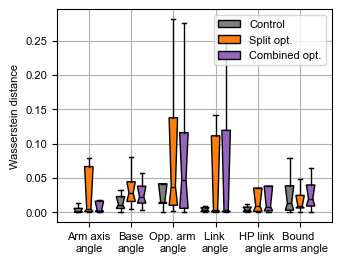

In [103]:
fig1=plt.figure(figsize=(9/2.54,7/2.54)  )  #(9/2.54,7/2.54)      #(3,3)   #(3.5/2.54,3.5/2.54)
#fig1=plt.figure(figsize=(9,3.5)  )
ax1 = fig1.add_subplot(111)


ax1.grid()

x_pos=np.arange(0,6)
s_fliers=False

bp_0=plt.boxplot([w_dist_aa_list_t,w_dist_ba_list_t,w_dist_oa_list_t,w_dist_la_list_t,w_dist_hp_list_t,w_dist_bm_list_t],positions=x_pos-0.25,showfliers=s_fliers,notch=True,bootstrap=10000, patch_artist=True, boxprops={'facecolor': 'tab:grey'},medianprops={'color': 'black'},widths=0.2)

bp_1=plt.boxplot([w_dist_aa_list,w_dist_ba_list,w_dist_oa_list,w_dist_la_list,w_dist_hp_list,w_dist_bm_list],positions=x_pos,showfliers=s_fliers,notch=True,bootstrap=10000, patch_artist=True, boxprops={'facecolor': 'tab:orange'},medianprops={'color': 'black'},widths=0.2)
bp_2=plt.boxplot([w_dist_aa_list2,w_dist_ba_list2,w_dist_oa_list2,w_dist_la_list2,w_dist_hp_list2,w_dist_bm_list2],positions=x_pos+0.25,showfliers=s_fliers,notch=True,bootstrap=10000, patch_artist=True, boxprops={'facecolor': 'tab:purple'},medianprops={'color': 'black'},widths=0.2)


fs1=8
#plt.xlim(-1,25)
ax1.legend([bp_0['boxes'][0],bp_1['boxes'][0], bp_2['boxes'][0]], ["Control",'Split opt.', 'Combined opt.'],prop={'family': 'Arial','size': fs1},loc="upper right")
ax1.set_ylabel("Wasserstein distance",fontname = "Arial",fontsize=fs1)
#ax1.set_xlabel("Angle [deg]",fontname = "Arial",fontsize=fs1)
plt.xticks(x_pos,["Arm axis\nangle","Base\nangle","Opp. arm \nangle","Link \nangle","HP link \nangle","Bound \narms angle"],fontname = "Arial",fontsize=fs1)
plt.yticks(fontname = "Arial",fontsize=fs1)

save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/opt_val_wasserstein_1.pdf"
#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

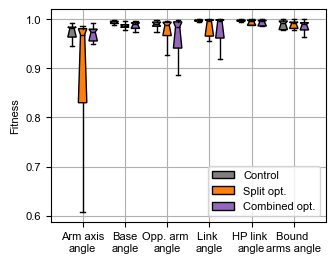

In [147]:
#fig1=plt.figure(figsize=(9/2.54,3.5/2.54)  )  #(9/2.54,7/2.54)      #(3,3)   #(3.5/2.54,3.5/2.54)
fig1=plt.figure(figsize=(9/2.54,7/2.54))
ax1 = fig1.add_subplot(111)


ax1.grid()

x_pos=np.arange(0,6)
s_fliers=False

bp_0=plt.boxplot([ft_aa_list_t,ft_ba_list_t,ft_oa_list_t,ft_la_list_t,ft_hp_list_t,ft_bm_list_t],positions=x_pos-0.25,showfliers=s_fliers,notch=True,bootstrap=10000, patch_artist=True, boxprops={'facecolor': 'tab:grey'},medianprops={'color': 'black'},widths=0.2)

bp_1=plt.boxplot([ft_aa_list,ft_ba_list,ft_oa_list,ft_la_list,ft_hp_list,ft_bm_list],positions=x_pos,showfliers=s_fliers,notch=True,bootstrap=10000, patch_artist=True, boxprops={'facecolor': 'tab:orange'},medianprops={'color': 'black'},widths=0.2)
bp_2=plt.boxplot([ft_aa_list2,ft_ba_list2,ft_oa_list2,ft_la_list2,ft_hp_list2,ft_bm_list2],positions=x_pos+0.25,showfliers=s_fliers,notch=True,bootstrap=10000, patch_artist=True, boxprops={'facecolor': 'tab:purple'},medianprops={'color': 'black'},widths=0.2)


fs1=8
#plt.xlim(-1,25)
ax1.legend([bp_0['boxes'][0],bp_1['boxes'][0], bp_2['boxes'][0]], ["Control",'Split opt.', 'Combined opt.'],prop={'family': 'Arial','size': fs1},loc="lower right")
ax1.set_ylabel("Fitness",fontname = "Arial",fontsize=fs1)
#ax1.set_xlabel("Angle [deg]",fontname = "Arial",fontsize=fs1)
plt.xticks(x_pos,["Arm axis\nangle","Base\nangle","Opp. arm \nangle","Link \nangle","HP link \nangle","Bound \narms angle"],fontname = "Arial",fontsize=fs1)
plt.yticks(fontname = "Arial",fontsize=fs1)
#plt.yscale("log")

save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/opt_val_fitness_1.pdf"
#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

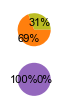

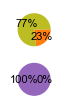

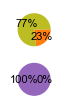

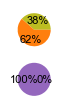

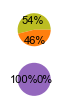

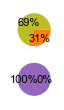

In [45]:
#Sanity check: for the corrected KS test, the validation and target angle distributions should not ne siginificantly different
fs1=8
thr_1=0.05
ks_list=[ks_aa_list_t,ks_ba_list_t,ks_oa_list_t,ks_la_list_t,ks_hp_list_t,ks_bm_list_t]# the uncorrected KS values
ks_list2=[ks_aa_list_cs_t,ks_ba_list_cs_t,ks_oa_list_cs_t,ks_la_list_cs_t,ks_hp_list_cs_t,ks_bm_list_cs_t]# the corrected KS values

for i in range(len(ks_list)):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(2/2.54, 3/2.54))
    ks_sel=ks_list[i]
    ks_sel2=ks_list2[i]
    ax1.pie([sum(thr_1>v for v in ks_sel),sum(thr_1<=v for v in ks_sel)], colors=["tab:olive","tab:orange"], startangle=0, autopct='%1.0f%%',textprops={'family': 'Arial','size': fs1})

    ax2.pie([sum(thr_1>v for v in ks_sel2),sum(thr_1<=v for v in ks_sel2)], colors=["tab:olive","tab:purple"], startangle=0, autopct='%1.0f%%',textprops={'family': 'Arial','size': fs1})

    #plt.show()
    save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/frac_distr_similar_ "+str(i)  + "_1.pdf"
    #plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

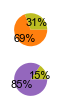

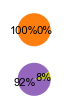

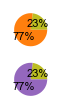

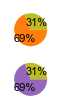

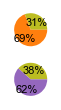

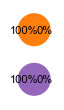

In [48]:
fs1=8
thr_1=0.05
ks_list=[ks_aa_list_cs,ks_ba_list_cs,ks_oa_list_cs,ks_la_list_cs,ks_hp_list_cs,ks_bm_list_cs]
ks_list2=[ks_aa_list_cs2,ks_ba_list_cs2,ks_oa_list_cs2,ks_la_list_cs2,ks_hp_list_cs2,ks_bm_list_cs2]

for i in range(len(ks_list)):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(2/2.54, 3/2.54))
    ks_sel=ks_list[i]
    ks_sel2=ks_list2[i]
    ax1.pie([sum(thr_1>v for v in ks_sel),sum(thr_1<=v for v in ks_sel)], colors=["tab:olive","tab:orange"], startangle=0, autopct='%1.0f%%',textprops={'family': 'Arial','size': fs1})

    ax2.pie([sum(thr_1>v for v in ks_sel2),sum(thr_1<=v for v in ks_sel2)], colors=["tab:olive","tab:purple"], startangle=0, autopct='%1.0f%%',textprops={'family': 'Arial','size': fs1})

    #plt.show()
    save_name_1="/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/frac_distr_similar_ "+str(i)  + "_corr_1.pdf"
    #plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

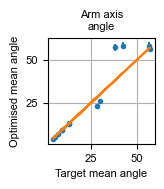

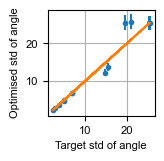

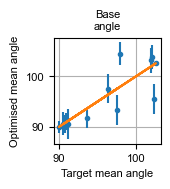

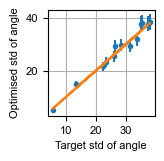

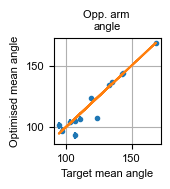

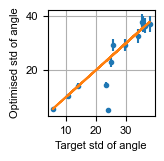

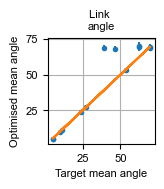

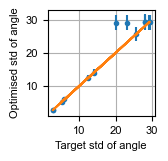

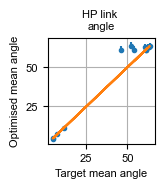

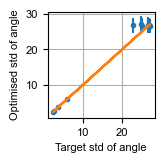

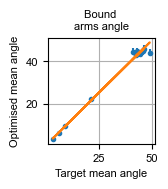

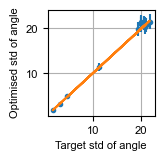

In [214]:
#mean and std of target and optimized angles


target_angle_values=[v_aa_list_t,v_ba_list_t,v_oa_list_t,v_la_list_t,v_hp_list_t,v_bm_list_t]

opt_angle_values=[v_aa_list,v_ba_list,v_oa_list,v_la_list,v_hp_list,v_bm_list]
opt_angle_values2=[v_aa_list2,v_ba_list2,v_oa_list2,v_la_list2,v_hp_list2,v_bm_list2]
angle_names=["Arm axis\nangle","Base\nangle","Opp. arm \nangle","Link \nangle","HP link \nangle","Bound \narms angle"]
for i in range(len(target_angle_values)):

    fig1=plt.figure(figsize=(3.5/2.54,3.5/2.54)) 
    #fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10/2.54, 3.5/2.54))
    ax1 = fig1.add_subplot(111)

    ax1.errorbar(np.mean(target_angle_values[i],axis=1)*180/np.pi, np.mean(opt_angle_values[i],axis=1)*180/np.pi,yerr=np.std(opt_angle_values[i],axis=1)/len(opt_angle_values[i])*180/np.pi,fmt=".")
    ax1.errorbar(np.mean(target_angle_values[i],axis=1)*180/np.pi, np.mean(target_angle_values[i],axis=1)*180/np.pi)

    fs1=8
    #plt.xlim(-1,110)
    #ax1.legend(loc="upper right",prop={'family': 'Arial','size': fs1})
    ax1.set_ylabel("Optimised mean angle",fontname = "Arial",fontsize=fs1)
    ax1.set_xlabel("Target mean angle",fontname = "Arial",fontsize=fs1)
    plt.xticks(fontname = "Arial",fontsize=fs1)
    plt.yticks(fontname = "Arial",fontsize=fs1)
    plt.title(angle_names[i],fontname = "Arial",fontsize=fs1)
    ax1.grid()

    fig2=plt.figure(figsize=(3.5/2.54,3.5/2.54)) 
    #fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10/2.54, 3.5/2.54))
    ax2 = fig2.add_subplot(111)

    ax2.errorbar(np.std(target_angle_values[i],axis=1)*180/np.pi, np.std(opt_angle_values[i],axis=1)*180/np.pi,yerr=np.std(opt_angle_values[i],axis=1)/len(opt_angle_values[i])*180/np.pi,fmt=".")
    ax2.errorbar(np.std(target_angle_values[i],axis=1)*180/np.pi, np.std(target_angle_values[i],axis=1)*180/np.pi)
    ax2.set_ylabel("Optimised std of angle",fontname = "Arial",fontsize=fs1)
    ax2.set_xlabel("Target std of angle",fontname = "Arial",fontsize=fs1)
    plt.xticks(fontname = "Arial",fontsize=fs1)
    plt.yticks(fontname = "Arial",fontsize=fs1)
    ax2.grid()

    

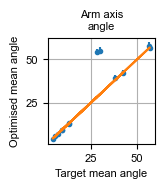

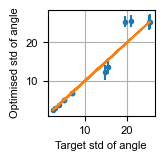

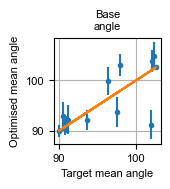

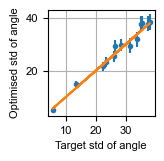

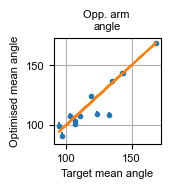

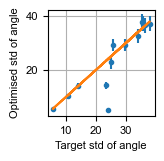

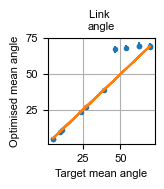

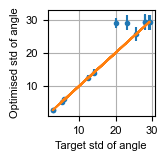

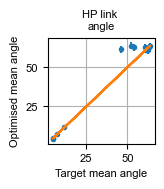

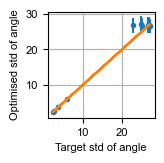

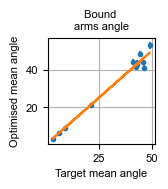

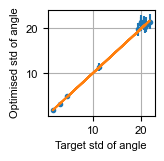

In [230]:
for i in range(len(target_angle_values)):

    fig1=plt.figure(figsize=(3.5/2.54,3.5/2.54)) 
    #fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10/2.54, 3.5/2.54))
    ax1 = fig1.add_subplot(111)

    ax1.errorbar(np.mean(target_angle_values[i],axis=1)*180/np.pi, np.mean(opt_angle_values2[i],axis=1)*180/np.pi,yerr=np.std(opt_angle_values2[i],axis=1)/len(opt_angle_values2[i])*180/np.pi,fmt=".")
    ax1.errorbar(np.mean(target_angle_values[i],axis=1)*180/np.pi, np.mean(target_angle_values[i],axis=1)*180/np.pi)

    fs1=8
    #plt.xlim(-1,110)
    #ax1.legend(loc="upper right",prop={'family': 'Arial','size': fs1})
    ax1.set_ylabel("Optimised mean angle",fontname = "Arial",fontsize=fs1)
    ax1.set_xlabel("Target mean angle",fontname = "Arial",fontsize=fs1)
    plt.xticks(fontname = "Arial",fontsize=fs1)
    plt.yticks(fontname = "Arial",fontsize=fs1)
    plt.title(angle_names[i],fontname = "Arial",fontsize=fs1)
    ax1.grid()

    fig2=plt.figure(figsize=(3.5/2.54,3.5/2.54)) 
    #fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10/2.54, 3.5/2.54))
    ax2 = fig2.add_subplot(111)

    ax2.errorbar(np.std(target_angle_values[i],axis=1)*180/np.pi, np.std(opt_angle_values[i],axis=1)*180/np.pi,yerr=np.std(opt_angle_values2[i],axis=1)/len(opt_angle_values2[i])*180/np.pi,fmt=".")
    ax2.errorbar(np.std(target_angle_values[i],axis=1)*180/np.pi, np.std(target_angle_values[i],axis=1)*180/np.pi)
    ax2.set_ylabel("Optimised std of angle",fontname = "Arial",fontsize=fs1)
    ax2.set_xlabel("Target std of angle",fontname = "Arial",fontsize=fs1)
    plt.xticks(fontname = "Arial",fontsize=fs1)
    plt.yticks(fontname = "Arial",fontsize=fs1)
    ax2.grid()

# Fitness as function of iterations during validation

In [68]:
%%time
#split optimisation
'''#get list of wasserstein distances of validation sims
w_dist_aa_list=[]
w_dist_ba_list=[]
w_dist_oa_list=[]
w_dist_la_list=[]

w_dist_hp_list=[]

w_dist_bm_list=[]'''

#fitnes
ft_aa_list_it=[]
ft_ba_oa_list_it=[]
ft_ba_list_it=[]
ft_oa_list_it=[]
ft_la_list_it=[]
ft_hp_list_it=[]
ft_bm_list_it=[]

'''#ks test
ks_aa_list=[]
ks_ba_list=[]
ks_oa_list=[]
ks_la_list=[]
ks_hp_list=[]
ks_bm_list=[]

#angle values
v_aa_list=[]
v_ba_list=[]
v_oa_list=[]
v_la_list=[]
v_hp_list=[]
v_bm_list=[]'''

for i in [0,1,2,3,4,5,6,7,8,9,10,11,12]:
    folder_n="/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_validation_bay_opt_sims_2_v1/D_target_id_"+str(i)+"/"

    #fitnes for each iteration
    ft_aa_list_it_e=[]
    ft_ba_oa_list_it_e=[]
    ft_ba_list_it_e=[]
    ft_oa_list_it_e=[]
    ft_la_list_it_e=[]
    ft_hp_list_it_e=[]
    ft_bm_list_it_e=[]
    #get target angles

    sel_val_target=i
    
    base_angle_distr_target=base_angle_distr_target_list[sel_val_target]
    link_angle_distr_target=link_angle_distr_target_list[sel_val_target]
    arm_axis_angle_distr_target=arm_axis_angle_distr_target_list[sel_val_target]
    oppa_angle_distr_target=oppa_angle_distr_target_list[sel_val_target]
    link_HP_angle_distr_target=link_HP_angle_distr_target_list[sel_val_target]
    angle_ds_fused_link_distr_target=angle_ds_fused_link_distr_target_list[sel_val_target]
    
    values_angle_base_target=values_angle_base_target_list[sel_val_target]
    values_angle_link_target=values_angle_link_target_list[sel_val_target]
    values_angle_arm_axis_target=values_angle_arm_axis_target_list[sel_val_target]
    values_angle_oppa_target=values_angle_oppa_target_list[sel_val_target]
    values_angle_link_HP_target=values_angle_link_HP_target_list[sel_val_target]
    values_angle_ds_fused_link_target=values_angle_ds_fused_link_target_list[sel_val_target]
    
    
    list_values_target_angles_1=[values_angle_base_target,values_angle_link_target,values_angle_arm_axis_target,values_angle_oppa_target,values_angle_link_HP_target,values_angle_ds_fused_link_target]

    #get trial angles

    #aa optimization:
    step_s=1
    step_s2=1
    for k in range(0,22,step_s):
        #aa
        folder_val_t=folder_n+"D_aa_opt_1/"
        names_val_t=["sim_aa_opt_1_"+str(((k*5)+1)+l)+".h5" for l in range(5)]
        print("aa",i,k)
        ft=eval_sim_c1_1_aa(folder=folder_val_t,names_sim_repeat=names_val_t,t_skip=300,t_lim=None,t_step=1,arm_axis_angle_distr_target=arm_axis_angle_distr_target)
        ft_aa_list_it_e.append(ft)


    #ba oa la optimization:
    for k in range(0,136,step_s2):
        #ba oa la
        folder_val_t=folder_n+"D_ba_oa_la_opt_1/"
        names_val_t=["sim_ba_oa_la_opt_1_"+str(((k*5)+1)+l)+".h5" for l in range(5)]
        print("ba oa la",i,k)
        #ba oa
        ft2=eval_sim_c1_2_ba_oa(folder=folder_val_t,names_sim_repeat=names_val_t,t_skip=300,t_lim=None,t_step=1,base_angle_distr_target=base_angle_distr_target,oppa_angle_distr_target=oppa_angle_distr_target)
        ft_ba_oa_list_it_e.append(ft2)
        #la
        ft3=eval_sim_c1_1_la(folder=folder_val_t,names_sim_repeat=names_val_t,t_skip=300,t_lim=None,t_step=1,link_angle_distr_target=link_angle_distr_target)
        ft_la_list_it_e.append(ft3)
    
    #hp optimization:
    for k in range(0,22,step_s):
        #hp
        folder_val_t=folder_n+"D_hp_opt_1/"
        names_val_t=["sim_hp_opt_1_"+str(((k*5)+1)+l)+".h5" for l in range(5)]
        print("hp",i,k)
        #hp
        ft4=eval_sim_c1_1_hp(folder=folder_val_t,names_sim_repeat=names_val_t,t_skip=300,t_lim=None,t_step=1,link_HP_angle_distr_target=link_HP_angle_distr_target)
        ft_hp_list_it_e.append(ft4)

    #bm optimization:
    for k in range(0,22,step_s):
        #bm
        folder_val_t=folder_n+"D_bm_opt_1/"
        names_val_t=["sim_bm_opt_1_"+str(((k*5)+1)+l)+".h5" for l in range(5)]
        print("bm",i,k)
        #bm
        ft5=eval_sim_c1_1_bm(folder=folder_val_t,names_sim_repeat=names_val_t,t_skip=300,t_lim=None,t_step=1,angle_ds_fused_link_distr_target=angle_ds_fused_link_distr_target)
        ft_bm_list_it_e.append(ft5)
 
 
    ft_aa_list_it.append(ft_aa_list_it_e)
    ft_ba_oa_list_it.append(ft_ba_oa_list_it_e)
    ft_la_list_it.append(ft_la_list_it_e)
    ft_hp_list_it.append(ft_hp_list_it_e)
    ft_bm_list_it.append(ft_bm_list_it_e)
    


aa 0 0
aa 0 1
aa 0 2
aa 0 3
aa 0 4
aa 0 5
aa 0 6
aa 0 7
aa 0 8
aa 0 9
aa 0 10
aa 0 11
aa 0 12
aa 0 13
aa 0 14
aa 0 15
aa 0 16
aa 0 17
aa 0 18
aa 0 19
aa 0 20
aa 0 21
ba oa la 0 0
ba oa la 0 1
ba oa la 0 2
ba oa la 0 3
ba oa la 0 4
ba oa la 0 5
ba oa la 0 6
ba oa la 0 7
ba oa la 0 8
ba oa la 0 9
ba oa la 0 10
ba oa la 0 11
ba oa la 0 12
ba oa la 0 13
ba oa la 0 14
ba oa la 0 15
ba oa la 0 16
ba oa la 0 17
ba oa la 0 18
ba oa la 0 19
ba oa la 0 20
ba oa la 0 21
ba oa la 0 22
ba oa la 0 23
ba oa la 0 24
ba oa la 0 25
ba oa la 0 26
ba oa la 0 27
ba oa la 0 28
ba oa la 0 29
ba oa la 0 30
ba oa la 0 31
ba oa la 0 32
ba oa la 0 33
ba oa la 0 34
ba oa la 0 35
ba oa la 0 36
ba oa la 0 37
ba oa la 0 38
ba oa la 0 39
ba oa la 0 40
ba oa la 0 41
ba oa la 0 42
ba oa la 0 43
ba oa la 0 44
ba oa la 0 45
ba oa la 0 46
ba oa la 0 47
ba oa la 0 48
ba oa la 0 49
ba oa la 0 50
ba oa la 0 51
ba oa la 0 52
ba oa la 0 53
ba oa la 0 54
ba oa la 0 55
ba oa la 0 56
ba oa la 0 57
ba oa la 0 58
ba oa la 0 59
ba o

In [13]:
%%time
#combined optimisation
'''#get list of wasserstein distances of validation sims
w_dist_aa_list=[]
w_dist_ba_list=[]
w_dist_oa_list=[]
w_dist_la_list=[]

w_dist_hp_list=[]

w_dist_bm_list=[]'''

#fitnes
#ft_aa_list_it=[]
ft_aa_ba_oa_list_it=[]
ft_ba_list_it=[]
ft_oa_list_it=[]
ft_la_list_it=[]
ft_hp_list_it=[]
ft_bm_list_it=[]

'''#ks test
ks_aa_list=[]
ks_ba_list=[]
ks_oa_list=[]
ks_la_list=[]
ks_hp_list=[]
ks_bm_list=[]

#angle values
v_aa_list=[]
v_ba_list=[]
v_oa_list=[]
v_la_list=[]
v_hp_list=[]
v_bm_list=[]'''

for i in [0,1,2,3,4,5,6,7,8,9,10,11,12]:
    folder_n="/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_validation_bay_opt_sims_2_v2/D_target_id_"+str(i)+"/"

    #fitnes for each iteration
    #ft_aa_list_it_e=[]
    ft_aa_ba_oa_list_it_e=[]
    ft_ba_list_it_e=[]
    ft_oa_list_it_e=[]
    ft_la_list_it_e=[]
    ft_hp_list_it_e=[]
    ft_bm_list_it_e=[]
    #get target angles

    sel_val_target=i
    
    base_angle_distr_target=base_angle_distr_target_list[sel_val_target]
    link_angle_distr_target=link_angle_distr_target_list[sel_val_target]
    arm_axis_angle_distr_target=arm_axis_angle_distr_target_list[sel_val_target]
    oppa_angle_distr_target=oppa_angle_distr_target_list[sel_val_target]
    link_HP_angle_distr_target=link_HP_angle_distr_target_list[sel_val_target]
    angle_ds_fused_link_distr_target=angle_ds_fused_link_distr_target_list[sel_val_target]
    
    values_angle_base_target=values_angle_base_target_list[sel_val_target]
    values_angle_link_target=values_angle_link_target_list[sel_val_target]
    values_angle_arm_axis_target=values_angle_arm_axis_target_list[sel_val_target]
    values_angle_oppa_target=values_angle_oppa_target_list[sel_val_target]
    values_angle_link_HP_target=values_angle_link_HP_target_list[sel_val_target]
    values_angle_ds_fused_link_target=values_angle_ds_fused_link_target_list[sel_val_target]
    
    
    list_values_target_angles_1=[values_angle_base_target,values_angle_link_target,values_angle_arm_axis_target,values_angle_oppa_target,values_angle_link_HP_target,values_angle_ds_fused_link_target]

    #get trial angles

    #aa optimization:
    step_s=1
    step_s2=1
    '''
    for k in range(0,22,step_s):
        #aa
        folder_val_t=folder_n+"D_aa_opt_1/"
        names_val_t=["sim_aa_opt_1_"+str(((k*5)+1)+l)+".h5" for l in range(5)]
        print("aa",i,k)
        ft=eval_sim_c1_1_aa(folder=folder_val_t,names_sim_repeat=names_val_t,t_skip=300,t_lim=None,t_step=1,arm_axis_angle_distr_target=arm_axis_angle_distr_target)
        ft_aa_list_it_e.append(ft)
    '''

    #aa ba oa la optimization:
    for k in range(0,152,step_s2):
        #ba oa la
        folder_val_t=folder_n+"D_aa_ba_oa_la_opt_1/"
        names_val_t=["sim_aa_ba_oa_la_opt_1_"+str(((k*5)+1)+l)+".h5" for l in range(5)]
        print("aa_ba oa la",i,k)
        #aa ba oa
        ft2=eval_sim_c1_3_aa_ba_oa(folder=folder_val_t,names_sim_repeat=names_val_t,t_skip=300,t_lim=None,t_step=1,arm_axis_angle_distr_target=arm_axis_angle_distr_target,base_angle_distr_target=base_angle_distr_target,oppa_angle_distr_target=oppa_angle_distr_target)
        ft_aa_ba_oa_list_it_e.append(ft2)
        #la
        ft3=eval_sim_c1_1_la(folder=folder_val_t,names_sim_repeat=names_val_t,t_skip=300,t_lim=None,t_step=1,link_angle_distr_target=link_angle_distr_target)
        ft_la_list_it_e.append(ft3)
    
    #hp optimization:
    for k in range(0,22,step_s):
        #hp
        folder_val_t=folder_n+"D_hp_opt_1/"
        names_val_t=["sim_hp_opt_1_"+str(((k*5)+1)+l)+".h5" for l in range(5)]
        print("hp",i,k)
        #hp
        ft4=eval_sim_c1_1_hp(folder=folder_val_t,names_sim_repeat=names_val_t,t_skip=300,t_lim=None,t_step=1,link_HP_angle_distr_target=link_HP_angle_distr_target)
        ft_hp_list_it_e.append(ft4)

    #bm optimization:
    for k in range(0,22,step_s):
        #bm
        folder_val_t=folder_n+"D_bm_opt_1/"
        names_val_t=["sim_bm_opt_1_"+str(((k*5)+1)+l)+".h5" for l in range(5)]
        print("bm",i,k)
        #bm
        ft5=eval_sim_c1_1_bm(folder=folder_val_t,names_sim_repeat=names_val_t,t_skip=300,t_lim=None,t_step=1,angle_ds_fused_link_distr_target=angle_ds_fused_link_distr_target)
        ft_bm_list_it_e.append(ft5)
 
 
    #ft_aa_list_it.append(ft_aa_list_it_e)
    ft_aa_ba_oa_list_it.append(ft_aa_ba_oa_list_it_e)
    ft_la_list_it.append(ft_la_list_it_e)
    ft_hp_list_it.append(ft_hp_list_it_e)
    ft_bm_list_it.append(ft_bm_list_it_e)
    


aa_ba oa la 0 0
aa_ba oa la 0 1
aa_ba oa la 0 2
aa_ba oa la 0 3
aa_ba oa la 0 4
aa_ba oa la 0 5
aa_ba oa la 0 6
aa_ba oa la 0 7
aa_ba oa la 0 8
aa_ba oa la 0 9
aa_ba oa la 0 10
aa_ba oa la 0 11
aa_ba oa la 0 12
aa_ba oa la 0 13
aa_ba oa la 0 14
aa_ba oa la 0 15
aa_ba oa la 0 16
aa_ba oa la 0 17
aa_ba oa la 0 18
aa_ba oa la 0 19
aa_ba oa la 0 20
aa_ba oa la 0 21
aa_ba oa la 0 22
aa_ba oa la 0 23
aa_ba oa la 0 24
aa_ba oa la 0 25
aa_ba oa la 0 26
aa_ba oa la 0 27
aa_ba oa la 0 28
aa_ba oa la 0 29
aa_ba oa la 0 30
aa_ba oa la 0 31
aa_ba oa la 0 32
aa_ba oa la 0 33
aa_ba oa la 0 34
aa_ba oa la 0 35
aa_ba oa la 0 36
aa_ba oa la 0 37
aa_ba oa la 0 38
aa_ba oa la 0 39
aa_ba oa la 0 40
aa_ba oa la 0 41
aa_ba oa la 0 42
aa_ba oa la 0 43
aa_ba oa la 0 44
aa_ba oa la 0 45
aa_ba oa la 0 46
aa_ba oa la 0 47
aa_ba oa la 0 48
aa_ba oa la 0 49
aa_ba oa la 0 50
aa_ba oa la 0 51
aa_ba oa la 0 52
aa_ba oa la 0 53
aa_ba oa la 0 54
aa_ba oa la 0 55
aa_ba oa la 0 56
aa_ba oa la 0 57
aa_ba oa la 0 58
aa_ba o

In [14]:
#np.save("/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_validation_bay_opt_sims_2_v1/fitness_evo_split_opt_v1_aa_1.npy",np.array(ft_aa_list_it))
#np.save("/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_validation_bay_opt_sims_2_v1/fitness_evo_split_opt_v1_ba_oa_1.npy",np.array(ft_ba_oa_list_it))
#np.save("/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_validation_bay_opt_sims_2_v1/fitness_evo_split_opt_v1_la_1.npy",np.array(ft_la_list_it))
#np.save("/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_validation_bay_opt_sims_2_v1/fitness_evo_split_opt_v1_hp_1.npy",np.array(ft_hp_list_it))
#np.save("/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_validation_bay_opt_sims_2_v1/fitness_evo_split_opt_v1_bm_1.npy",np.array(ft_bm_list_it))


#np.save("/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_validation_bay_opt_sims_2_v2/fitness_evo_split_opt_v1_aa_ba_oa_1.npy",np.array(ft_aa_ba_oa_list_it))
#np.save("/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_validation_bay_opt_sims_2_v2/fitness_evo_split_opt_v1_la_1.npy",np.array(ft_la_list_it))
#np.save("/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_validation_bay_opt_sims_2_v2/fitness_evo_split_opt_v1_hp_1.npy",np.array(ft_hp_list_it))
#np.save("/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_validation_bay_opt_sims_2_v2/fitness_evo_split_opt_v1_bm_1.npy",np.array(ft_bm_list_it))


In [11]:
 
#load previously saved fitness tracks
ft_aa_list_it=np.load("/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_validation_bay_opt_sims_2_v1/fitness_evo_split_opt_v1_aa_1.npy")
ft_ba_oa_list_it=np.load("/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_validation_bay_opt_sims_2_v1/fitness_evo_split_opt_v1_ba_oa_1.npy")
ft_la_list_it=np.load("/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_validation_bay_opt_sims_2_v1/fitness_evo_split_opt_v1_la_1.npy")
ft_hp_list_it=np.load("/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_validation_bay_opt_sims_2_v1/fitness_evo_split_opt_v1_hp_1.npy")
ft_bm_list_it=np.load("/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_validation_bay_opt_sims_2_v1/fitness_evo_split_opt_v1_bm_1.npy")


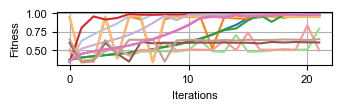

In [24]:
fig=plt.figure(figsize=(9/2.54,3.5/2.54 *0.5))
ax1 = fig.add_subplot(111)
colors_s = plt.cm.tab20.colors
for i in range(len(ft_aa_list_it)):
    plt.errorbar(np.arange(0,len(ft_aa_list_it[0])),ft_aa_list_it[i],color=colors_s[i])

fs1=8

plt.grid()

plt.xticks([0,10,20],fontname = "Arial",fontsize=fs1)
plt.yticks([0.5,0.75,1],fontname = "Arial",fontsize=fs1)

ax1.set_ylabel("Fitness",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Iterations",fontname = "Arial",fontsize=fs1)
#ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")

#ax1.xaxis.set_minor_locator(matplotlib.ticker.LogLocator(base=10.0, subs='auto', numticks=10))
#ax1.yaxis.set_minor_locator(matplotlib.ticker.LogLocator(base=10.0, subs='auto', numticks=10))

save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/fitness_validation_aa_1.pdf"

#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")



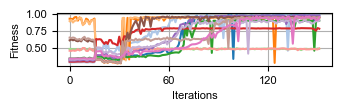

In [16]:
fig=plt.figure(figsize=(9/2.54,3.5/2.54 *0.5))
ax1 = fig.add_subplot(111)
colors_s = plt.cm.tab20.colors
for i in range(len(ft_aa_ba_oa_list_it)): #ft_ba_oa_list_it
    #plt.errorbar(np.arange(0,len(ft_ba_oa_list_it[0])),ft_ba_oa_list_it[i],color=colors_s[i])
    plt.errorbar(np.arange(0,len(ft_aa_ba_oa_list_it[0])),ft_aa_ba_oa_list_it[i],color=colors_s[i])

    #plt.scatter(np.arange(0,len(ft_ba_oa_list_it[0])),ft_ba_oa_list_it[i],s=1)


fs1=8

plt.grid()

plt.xticks([0,60,120],fontname = "Arial",fontsize=fs1)
plt.yticks([0.5,0.75,1],fontname = "Arial",fontsize=fs1)

ax1.set_ylabel("Fitness",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Iterations",fontname = "Arial",fontsize=fs1)
#ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")

#ax1.xaxis.set_minor_locator(matplotlib.ticker.LogLocator(base=10.0, subs='auto', numticks=10))
#ax1.yaxis.set_minor_locator(matplotlib.ticker.LogLocator(base=10.0, subs='auto', numticks=10))

save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/fitness_validation_ba_oa_1.pdf"

#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

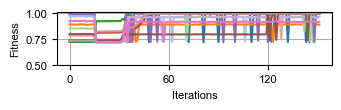

In [18]:
fig=plt.figure(figsize=(9/2.54,3.5/2.54 *0.5))
ax1 = fig.add_subplot(111)
colors_s = plt.cm.tab20.colors
for i in range(len(ft_la_list_it)):
    plt.errorbar(np.arange(0,len(ft_la_list_it[0])),ft_la_list_it[i],color=colors_s[i])

fs1=8

plt.grid()

plt.xticks([0,60,120],fontname = "Arial",fontsize=fs1)
plt.yticks([0.5,0.75,1],fontname = "Arial",fontsize=fs1)

ax1.set_ylabel("Fitness",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Iterations",fontname = "Arial",fontsize=fs1)
#ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")

#ax1.xaxis.set_minor_locator(matplotlib.ticker.LogLocator(base=10.0, subs='auto', numticks=10))
#ax1.yaxis.set_minor_locator(matplotlib.ticker.LogLocator(base=10.0, subs='auto', numticks=10))

save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/fitness_validation_la_1.pdf"

#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

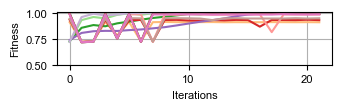

In [19]:
fig=plt.figure(figsize=(9/2.54,3.5/2.54 *0.5))
ax1 = fig.add_subplot(111)
colors_s = plt.cm.tab20.colors
for i in range(len(ft_hp_list_it)):
    plt.errorbar(np.arange(0,len(ft_hp_list_it[0])),ft_hp_list_it[i],color=colors_s[i])

fs1=8

plt.grid()

plt.xticks([0,10,20],fontname = "Arial",fontsize=fs1)
plt.yticks([0.5,0.75,1],fontname = "Arial",fontsize=fs1)

ax1.set_ylabel("Fitness",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Iterations",fontname = "Arial",fontsize=fs1)
#ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")

#ax1.xaxis.set_minor_locator(matplotlib.ticker.LogLocator(base=10.0, subs='auto', numticks=10))
#ax1.yaxis.set_minor_locator(matplotlib.ticker.LogLocator(base=10.0, subs='auto', numticks=10))

save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/fitness_validation_hp_1.pdf"

#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

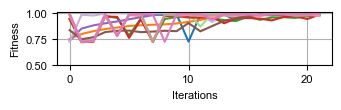

In [20]:
fig=plt.figure(figsize=(9/2.54,3.5/2.54 *0.5))
ax1 = fig.add_subplot(111)
colors_s = plt.cm.tab20.colors
for i in range(len(ft_bm_list_it)):
    plt.errorbar(np.arange(0,len(ft_bm_list_it[0])),ft_bm_list_it[i],color=colors_s[i])

fs1=8

plt.grid()

plt.xticks([0,10,20],fontname = "Arial",fontsize=fs1)
plt.yticks([0.5,0.75,1],fontname = "Arial",fontsize=fs1)

ax1.set_ylabel("Fitness",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Iterations",fontname = "Arial",fontsize=fs1)
#ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")

#ax1.xaxis.set_minor_locator(matplotlib.ticker.LogLocator(base=10.0, subs='auto', numticks=10))
#ax1.yaxis.set_minor_locator(matplotlib.ticker.LogLocator(base=10.0, subs='auto', numticks=10))

save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/fitness_validation_bm_1.pdf"

#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

# Compare validation of optimization strategies

## Arm axis angle

CPU times: user 1.21 s, sys: 1.8 s, total: 3.01 s
Wall time: 3.58 s


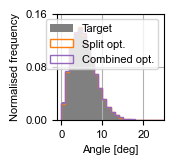

In [174]:
%%time
#compare validation optimisation


#sim from validation version 1
folder_names_init_sim="/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_validation_bay_opt_sims_2_v1/D_target_id_1/D_opt_sim_1/"
names_ini1="x_opt_test_1_"

#sim from validation version 1
folder_names_opt_sim1="/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_validation_bay_opt_sims_2_v2/D_target_id_1/D_opt_sim_1/"


names_opt1="x_opt_test_1_"


names_angle_eval=[[names_ini1+str(l+0)+".h5" for l in range(5)]
                 ,[names_opt1+str(l+0)+".h5" for l in range(5)]]

folders_angle_eval=[folder_names_init_sim,
                   folder_names_opt_sim1]

colours_l=["tab:orange","tab:purple"]
names_l=["Split opt.","Combined opt."]

fig1=plt.figure(figsize=(3.5/2.54,3.5/2.54))        #(3,3)
ax1 = fig1.add_subplot(111)
values_angle_arm_axis_target_s=values_angle_arm_axis_target_list[1]
sel_target_angle_distr=ax1.hist(values_angle_arm_axis_target_s*180/np.pi,bins=np.arange(0,190,1),density=True, histtype='bar',ls="-",color="grey",label="Target")[0]

for i in range(len(names_angle_eval)):
    base_angle_distr_ex_1,link_angle_distr_ex_1,arm_axis_angle_distr_ex_1,oppa_angle_distr_ex_1     ,values_angle_base_ex_1,values_angle_link_ex_1,values_angle_arm_axis_ex_1,values_angle_oppa_ex_test_1=cg_angle_distr_c1_4_ba_aa_oa_la(folder=folders_angle_eval[i],names_sim_repeat=names_angle_eval[i],t_skip=300,t_lim=None,t_step=1)
    list_angles_eval=[values_angle_base_ex_1,values_angle_link_ex_1,values_angle_arm_axis_ex_1,values_angle_oppa_ex_test_1]

    sel_angle_distr=ax1.hist(values_angle_arm_axis_ex_1*180/np.pi,bins=np.arange(0,190,1),density=True,color=colours_l[i], histtype='step',label=names_l[i])[0]

fs1=8
plt.xlim(-1,25)
ax1.legend(loc="upper right",prop={'family': 'Arial','size': fs1})
ax1.set_ylabel("Normalised frequency",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Angle [deg]",fontname = "Arial",fontsize=fs1)
plt.xticks([0,10,20],fontname = "Arial",fontsize=fs1)
plt.yticks([0,0.08,0.16],fontname = "Arial",fontsize=fs1)

ax1.grid()

#plt.savefig("ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/val_arm_axis_angle_ex1_1.pdf",format="pdf",bbox_inches="tight")



## Base angle

CPU times: user 312 ms, sys: 580 ms, total: 892 ms
Wall time: 2.69 s


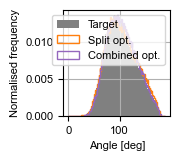

In [229]:
%%time
#compare validation optimisation


#sim from validation version 1
folder_names_init_sim="/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_validation_bay_opt_sims_2_v1/D_target_id_12/D_opt_sim_1/"
names_ini1="x_opt_test_1_"

#sim from validation version 1
folder_names_opt_sim1="/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_validation_bay_opt_sims_2_v2/D_target_id_12/D_opt_sim_1/"


names_opt1="x_opt_test_1_"


names_angle_eval=[[names_ini1+str(l+0)+".h5" for l in range(5)]
                 ,[names_opt1+str(l+0)+".h5" for l in range(5)]]

folders_angle_eval=[folder_names_init_sim,
                   folder_names_opt_sim1]

colours_l=["tab:orange","tab:purple"]
names_l=["Split opt.","Combined opt."]

fig1=plt.figure(figsize=(3.5/2.54,3.5/2.54))        #(3,3)
ax1 = fig1.add_subplot(111)

values_angle_base_target_list_s=values_angle_base_target_list[12]
sel_target_angle_distr=ax1.hist(values_angle_base_target_list_s*180/np.pi,bins=np.arange(0,190,1),density=True, histtype='bar',ls="-",color="grey",label="Target")[0]

for i in range(len(names_angle_eval)):
    base_angle_distr_ex_1,link_angle_distr_ex_1,arm_axis_angle_distr_ex_1,oppa_angle_distr_ex_1     ,values_angle_base_ex_1,values_angle_link_ex_1,values_angle_arm_axis_ex_1,values_angle_oppa_ex_test_1=cg_angle_distr_c1_4_ba_aa_oa_la(folder=folders_angle_eval[i],names_sim_repeat=names_angle_eval[i],t_skip=300,t_lim=None,t_step=1)
    list_angles_eval=[values_angle_base_ex_1,values_angle_link_ex_1,values_angle_arm_axis_ex_1,values_angle_oppa_ex_test_1]

    sel_angle_distr=ax1.hist(values_angle_base_ex_1*180/np.pi,bins=np.arange(0,190,1),density=True,color=colours_l[i], histtype='step',label=names_l[i])[0]

fs1=8
#plt.xlim(-1,25)
ax1.legend(loc="upper right",prop={'family': 'Arial','size': fs1})
ax1.set_ylabel("Normalised frequency",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Angle [deg]",fontname = "Arial",fontsize=fs1)
plt.xticks(fontname = "Arial",fontsize=fs1)
plt.yticks(fontname = "Arial",fontsize=fs1)

ax1.grid()

#plt.savefig("ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/val_arm_axis_angle_ex1_1.pdf",format="pdf",bbox_inches="tight")

## Link angle

CPU times: user 695 ms, sys: 1.59 s, total: 2.28 s
Wall time: 4.17 s


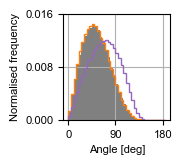

In [173]:
%%time
#compare validation optimisation
#sim from validation version 1
folder_names_init_sim="/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_validation_bay_opt_sims_2_v1/D_target_id_12/D_opt_sim_1/"
names_ini1="x_opt_test_1_"

#sim from validation version 1
folder_names_opt_sim1="/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_validation_bay_opt_sims_2_v2/D_target_id_12/D_opt_sim_1/"


names_opt1="x_opt_test_1_"
names_angle_eval=[[names_ini1+str(l+0)+".h5" for l in range(5)]
                 ,[names_opt1+str(l+0)+".h5" for l in range(5)]]

folders_angle_eval=[folder_names_init_sim,
                   folder_names_opt_sim1]

colours_l=["tab:orange","tab:purple"]
names_l=["Split opt.","Combined opt."]


fig1=plt.figure(figsize=(3.5/2.54,3.5/2.54)) 
ax1 = fig1.add_subplot(111)
values_angle_link_target_s=values_angle_link_target_list[12]

sel_target_angle_distr=ax1.hist(values_angle_link_target_s*180/np.pi,bins=np.arange(0,190,5),density=True, histtype='bar',ls="-",color="grey",label="Target")[0]

for i in range(len(names_angle_eval)):
    base_angle_distr_ex_1,link_angle_distr_ex_1,arm_axis_angle_distr_ex_1,oppa_angle_distr_ex_1     ,values_angle_base_ex_1,values_angle_link_ex_1,values_angle_arm_axis_ex_1,values_angle_oppa_ex_test_1=cg_angle_distr_c1_4_ba_aa_oa_la(folder=folders_angle_eval[i],names_sim_repeat=names_angle_eval[i],t_skip=300,t_lim=None,t_step=1)
    list_angles_eval=[values_angle_base_ex_1,values_angle_link_ex_1,values_angle_arm_axis_ex_1,values_angle_oppa_ex_test_1]

    sel_angle_distr=ax1.hist(values_angle_link_ex_1*180/np.pi,bins=np.arange(0,190,5),density=True, color=colours_l[i],histtype='step',label=names_l[i])[0]

fs1=8
#plt.xlim(-1,65)
#ax1.legend(loc="upper right",prop={'family': 'Arial','size': fs1})
ax1.set_ylabel("Normalised frequency",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Angle [deg]",fontname = "Arial",fontsize=fs1)
plt.xticks([0,90,180],fontname = "Arial",fontsize=fs1)
plt.yticks([0,0.008,0.016],fontname = "Arial",fontsize=fs1)
ax1.grid()


#plt.savefig("ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/val_link_angle_ex1_1.pdf",format="pdf",bbox_inches="tight")

